In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.feature_selection import VarianceThreshold, SelectKBest, mutual_info_classif, RFE
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve, precision_recall_curve, auc
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.inspection import PartialDependenceDisplay, permutation_importance

from xgboost import XGBClassifier

from lightgbm import LGBMClassifier

import shap

from PyALE import ale

from pathlib import Path

import joblib

E:\Python\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Block 1. Data Preparation

# Task 1. Load the Dataset

In [2]:
BASE_DIR = Path.cwd().parent
df = pd.read_csv(BASE_DIR / "data" / "ml" / "customer_churn.csv")

# Display first 5 rows

In [3]:
df.head()

,customer_id,country,age,device,premium_user,orders_count,total_revenue,avg_order_value,sessions_count,avg_session_duration,avg_pages_viewed,is_churned
0,4448,UA,33,desktop,0,0,0,0,31,15.65,5.35,0
1,3426,UA,30,mobile,1,0,0,0,26,16.77,5.96,0
2,295,HU,44,desktop,0,1,3,3,28,11.93,6.14,1
3,2997,UA,58,desktop,1,1,11,11,23,14.33,6.17,1
4,3182,UA,23,tablet,0,1,21,21,22,17.12,5.95,0


# Display shape

In [4]:
df.shape

(5000, 12)

# Display column names

In [5]:
df.columns

Index(['customer_id', 'country', 'age', 'device', 'premium_user',
       'orders_count', 'total_revenue', 'avg_order_value', 'sessions_count',
       'avg_session_duration', 'avg_pages_viewed', 'is_churned'],
      dtype='str')

# Display column types

In [6]:
df.dtypes

customer_id               int64
country                     str
age                       int64
device                      str
premium_user              int64
orders_count              int64
total_revenue             int64
avg_order_value           int64
sessions_count            int64
avg_session_duration    float64
avg_pages_viewed        float64
is_churned                int64
dtype: object

# Task 2. Exploratory Data Analysis (EDA)

# Check the number of rows

In [7]:
len(df)

5000

# Check the number of customers

In [8]:
len(df['customer_id'].unique())

5000

# Check the number of features

In [9]:
df.drop(columns= 'is_churned').columns.size

11

# Define numerical columns

In [10]:
num_cols = df.drop(columns= ["is_churned", 'customer_id']).select_dtypes(include="number").columns
print("The number of numerical columns: ", len(num_cols))
print(num_cols)

The number of numerical columns:  8
Index(['age', 'premium_user', 'orders_count', 'total_revenue',
       'avg_order_value', 'sessions_count', 'avg_session_duration',
       'avg_pages_viewed'],
      dtype='str')


# Define categorical columns

In [11]:
cat_cols = df.drop(columns= "is_churned").select_dtypes(exclude="number").columns
print("The number of categorical columns: ", len(cat_cols))
print(cat_cols)

The number of categorical columns:  2
Index(['country', 'device'], dtype='str')


# Check missing values

In [12]:
df.isna().sum()

customer_id             0
country                 0
age                     0
device                  0
premium_user            0
orders_count            0
total_revenue           0
avg_order_value         0
sessions_count          0
avg_session_duration    0
avg_pages_viewed        0
is_churned              0
dtype: int64

# Check duplicate values

In [13]:
df.duplicated().sum()

np.int64(0)

# Display age distribution

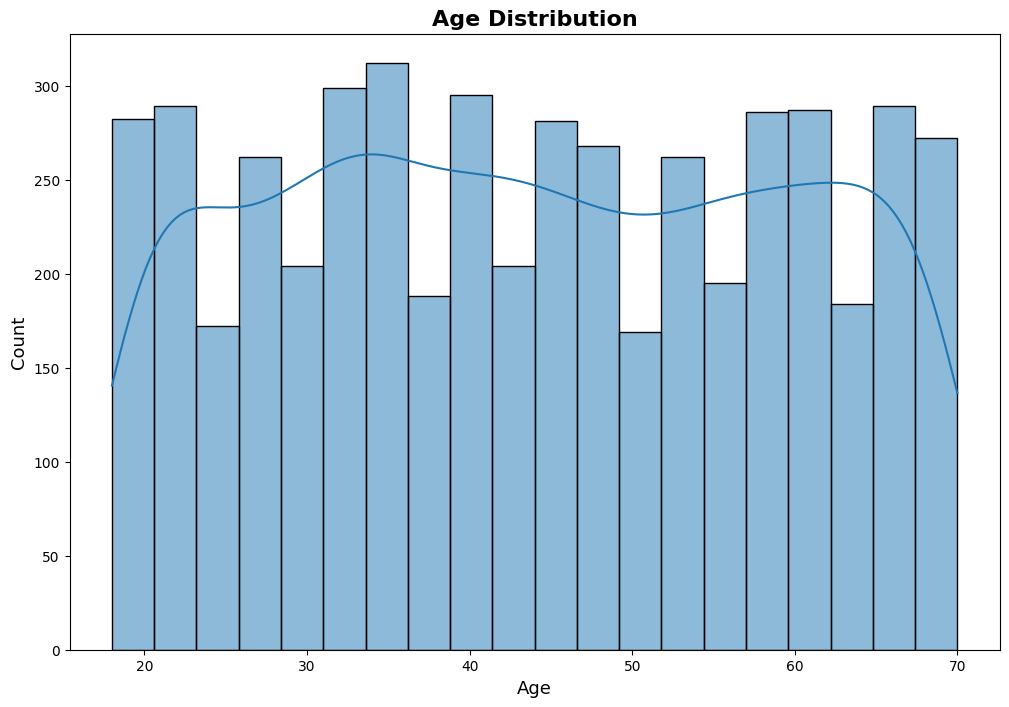

In [14]:
plt.figure(figsize = (12, 8))
sns.histplot(data = df, x = 'age', bins = 20, kde=True)

plt.title("Age Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Age", fontsize = 13)
plt.ylabel("Count", fontsize = 13)

plt.show()

# Display total revenue distribution

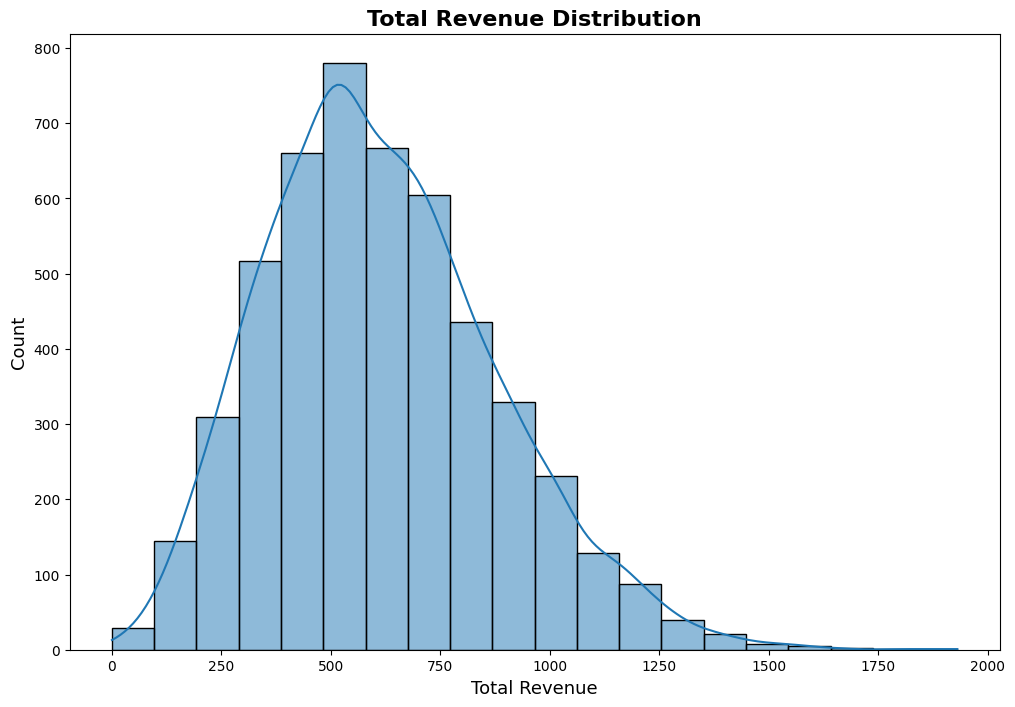

In [15]:
plt.figure(figsize = (12, 8))
sns.histplot(data = df, x = 'total_revenue', bins = 20, kde=True)

plt.title("Total Revenue Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Total Revenue", fontsize = 13)
plt.ylabel("Count", fontsize = 13)

plt.show()

# Display correlation heatmap

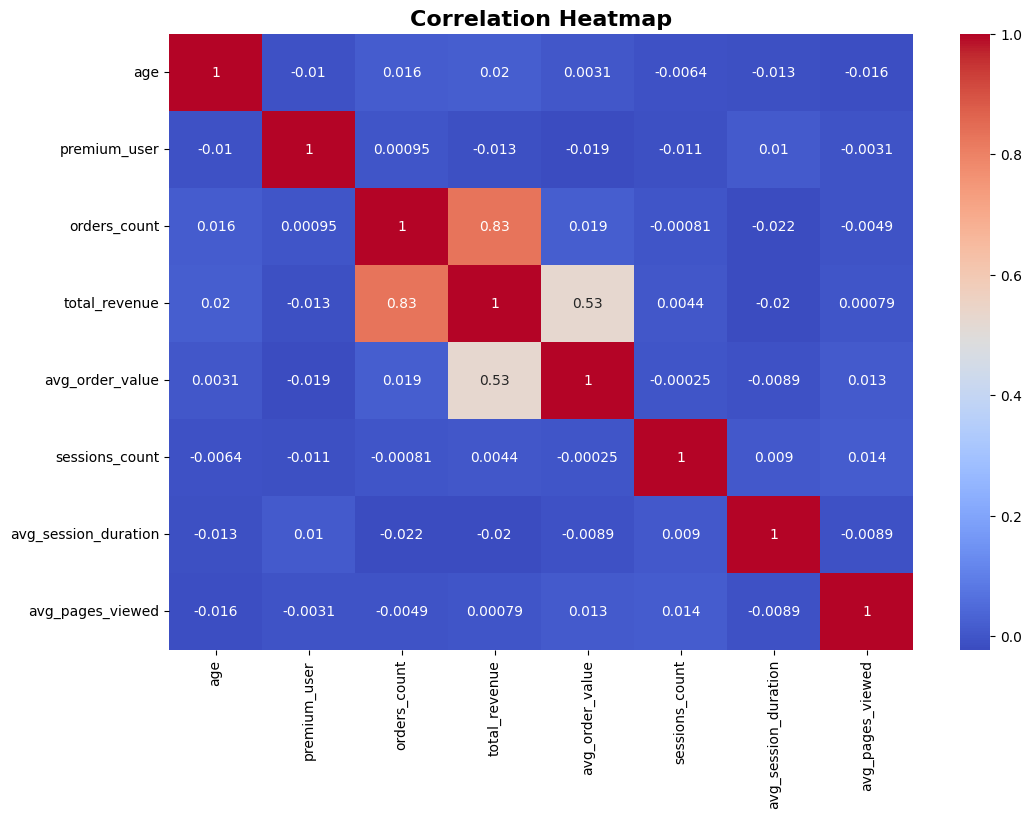

In [16]:
plt.figure(figsize = (12, 8))
data = df[num_cols].corr()
sns.heatmap(data, cmap = "coolwarm", annot=True)

plt.title("Correlation Heatmap", fontsize=16, fontweight="bold")

plt.show()

# Task 3. Check target distribution

In [17]:
target_count = df['is_churned'].value_counts()
pd.DataFrame({
    'count': target_count,
    'percent': (target_count * 100 / len(df)).round(2).apply(lambda x: f'{x}%')
})

,count,percent
is_churned,,
0,3258,65.16%
1,1742,34.84%


# Display target distribution

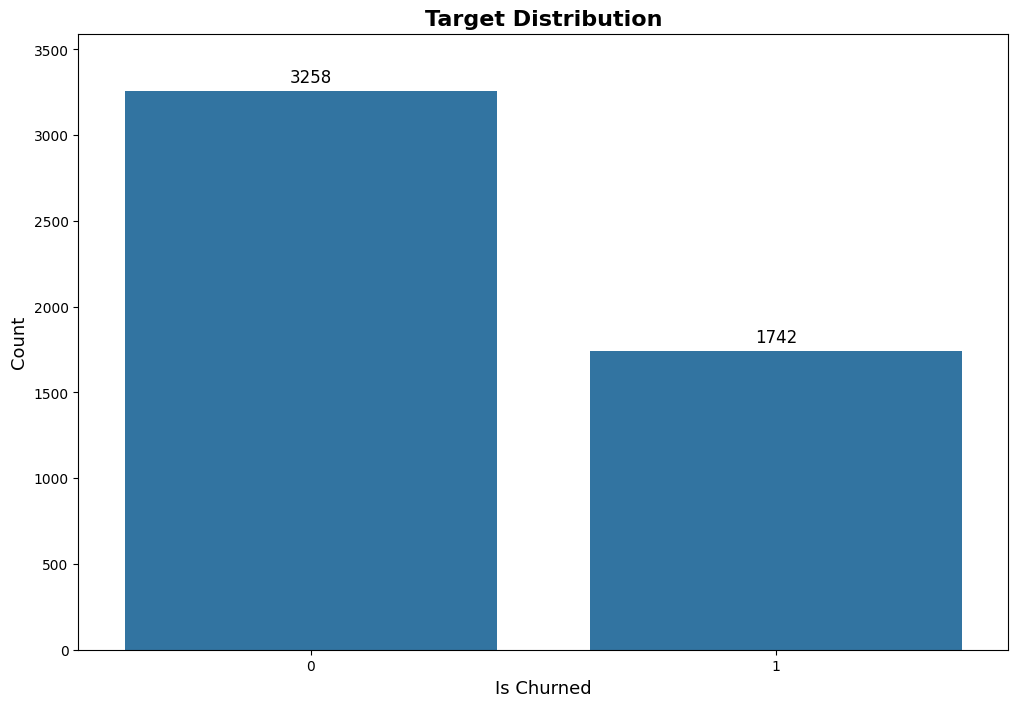

In [18]:
plt.figure(figsize = (12, 8))
ax = sns.countplot(data = df, x = 'is_churned')
for container in ax.containers:
    ax.bar_label(container, fontsize = 12, padding = 3)
y_min, y_max = ax.get_ylim()
ax.set_ylim(y_min,  y_max * 1.05)

plt.title("Target Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Is Churned", fontsize = 13)
plt.ylabel("Count", fontsize = 13)

plt.show()

# Block 2. Data Splitting

# Task 4. Divide the data into x and y

In [19]:
X = df.drop(columns= 'is_churned')
y = df['is_churned']

# Task 5. Split the Dataset

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y)

# Block 3. Baseline Models

# Task 6. Train LogisticRegression

In [21]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(), cat_cols)
])

lg_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(random_state=42, max_iter=1000))
])
lg_pipeline.fit(X_train, y_train)
lg_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

# Task 7. Train RandomForestClassifier

In [22]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(), cat_cols)
])

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])
rf_pipeline.fit(X_train, y_train)
rf_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

# Task 8. Evaluate models

In [23]:
pipelines = {"Logistic Regression": lg_pipeline, "Random Forest": rf_pipeline}
results = []
for name, pipeline in pipelines.items():
    pred = pipeline.predict(X_test)
    proba = pipeline.predict_proba(X_test)[:, 1]
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, proba)
    })
results = pd.DataFrame(results)
results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.769,0.709677,0.568966,0.631579,0.815678
1,Random Forest,0.767,0.691030,0.597701,0.640986,0.847864


# Confusion Matrix

In [24]:
lg_pred = lg_pipeline.predict(X_test)
lg_cf = confusion_matrix(y_test, lg_pred)
print("Logistic Regression:\n ", lg_cf)

rf_pred = rf_pipeline.predict(X_test)
rf_cf = confusion_matrix(y_test, rf_pred)
print("Random Forest Classifier:\n ", rf_cf)

Logistic Regression:
  [[571  81]
 [150 198]]
Random Forest Classifier:
  [[559  93]
 [140 208]]


# Visualize results

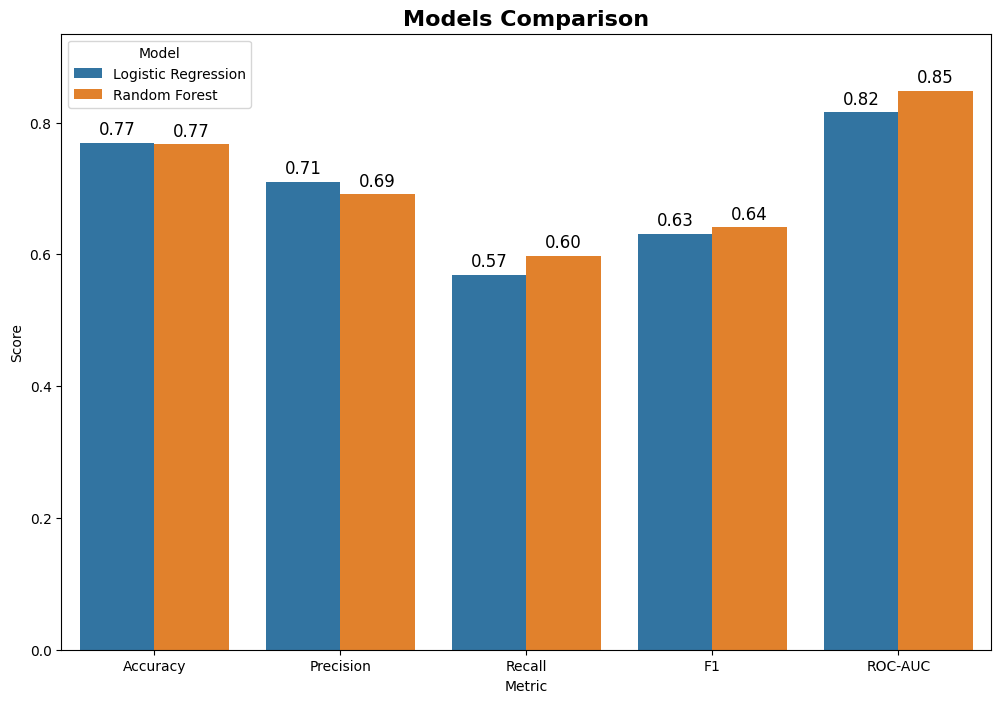

In [25]:
plt.figure(figsize = (12, 8))
results_melted = results.melt(id_vars='Model', var_name='Metric', value_name='Score')
ax = sns.barplot(data= results_melted, x= 'Metric', y= 'Score', hue= 'Model')
for container in ax.containers:
    ax.bar_label(container, fontsize = 12, fmt= '%.2f', padding = 3)
y_min, y_max = ax.get_ylim()
ax.set_ylim(y_min,  y_max * 1.05)

plt.title("Models Comparison", fontsize=16, fontweight="bold")
plt.show()

# Task 9. Cross-validation

In [26]:
results = []
cv = StratifiedKFold(n_splits= 5, shuffle= True, random_state= 42)
for name, pipeline in pipelines.items():
    cvs = cross_val_score(estimator= pipeline, X= X_train, y= y_train, scoring= 'roc_auc', cv= cv)
    results.append({
        'Model': name,
        'Score': cvs.mean()
    })
results = pd.DataFrame(results)
results

,Model,Score
0,Logistic Regression,0.825785
1,Random Forest,0.856114


# Visualize results

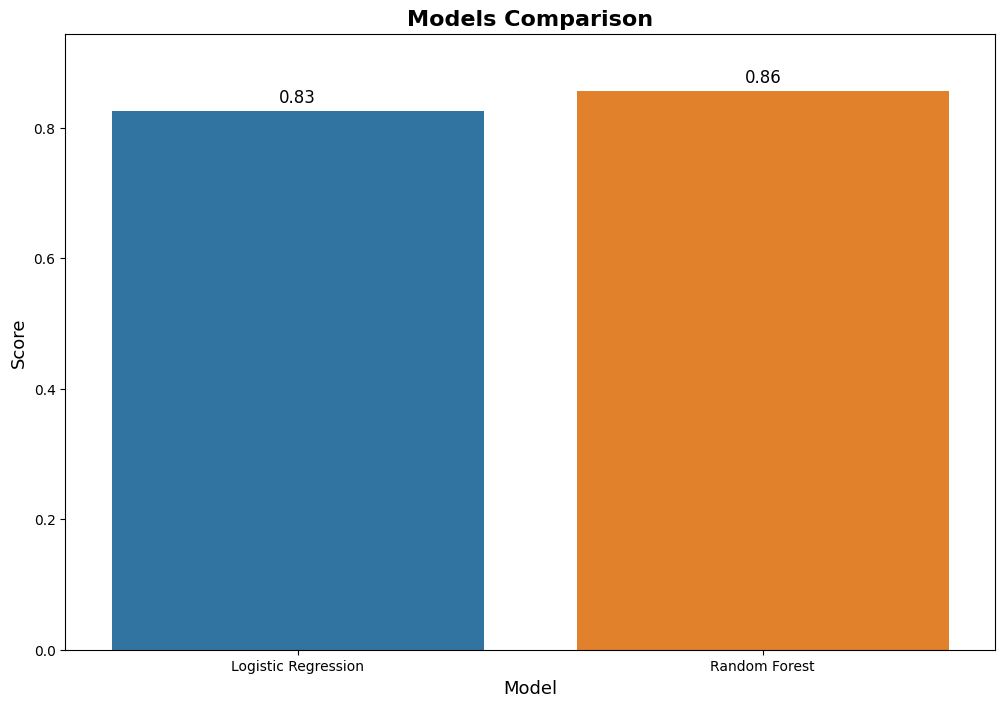

In [27]:
plt.figure(figsize = (12, 8))
ax = sns.barplot(data= results, x= 'Model', y= 'Score', hue= 'Model')
for container in ax.containers:
    ax.bar_label(container, fontsize = 12, fmt= '%.2f', padding = 3)
y_min, y_max = ax.get_ylim()
ax.set_ylim(y_min,  y_max * 1.05)

plt.title("Models Comparison", fontsize=16, fontweight="bold")
plt.xlabel("Model", fontsize = 13)
plt.ylabel("Score", fontsize = 13)

plt.show()

# Block 4. Hyperparameter Tuning

# Task 10. Hyperparameter Tuning

In [28]:
params = {"model__n_estimators": [100, 300, 500],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt", "log2"]}

grid = GridSearchCV(estimator = rf_pipeline, param_grid = params, n_jobs = -1, scoring = 'roc_auc', cv = cv, verbose = 2)
grid.fit(X_train, y_train)

print("Best params", grid.best_params_)
print("Best score", grid.best_score_)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best params {'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 500}
Best score 0.8620410067834532


# Task 11. Compare the model before and after tuning

In [29]:
tun_rf_pipeline = grid.best_estimator_
rf_pipelines = {"Random Forest": rf_pipeline, "Tunning Random Forest": tun_rf_pipeline}
results = []
for name, pipeline in rf_pipelines.items():
    pred = pipeline.predict(X_test)
    proba = pipeline.predict_proba(X_test)[:, 1]
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, proba)
    })
results = pd.DataFrame(results)
results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Random Forest,0.767,0.69103,0.597701,0.640986,0.847864
1,Tunning Random Forest,0.772,0.70000,0.603448,0.648148,0.859544


# Visualize results

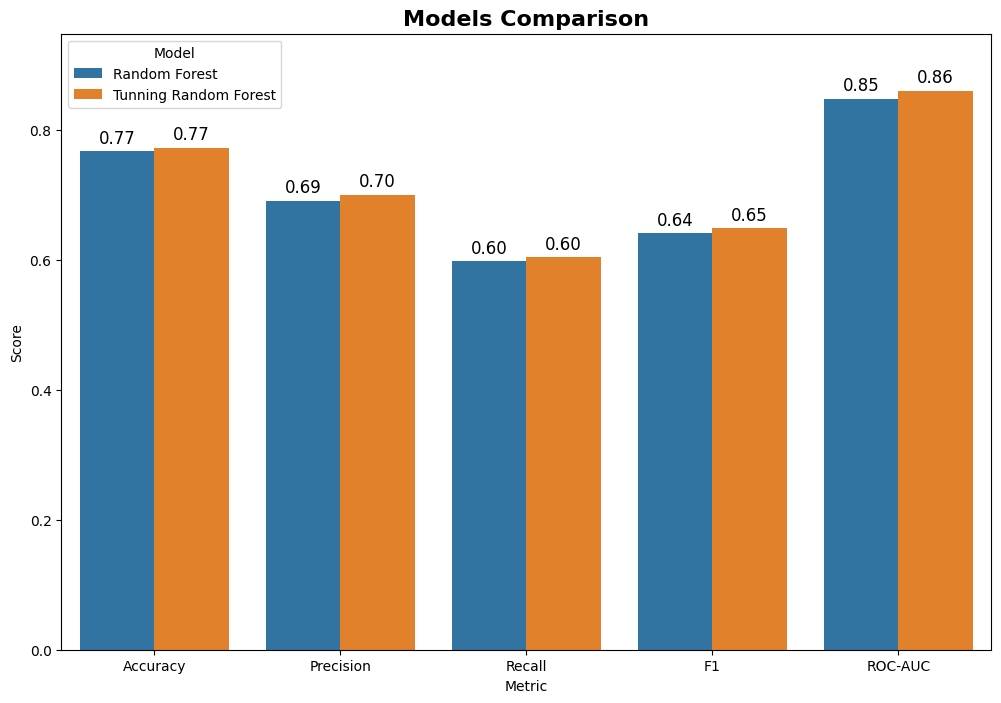

In [30]:
plt.figure(figsize = (12, 8))
results_melted = results.melt(id_vars='Model', var_name='Metric', value_name='Score')
ax = sns.barplot(data= results_melted, x= 'Metric', y= 'Score', hue= 'Model')
for container in ax.containers:
    ax.bar_label(container, fontsize = 12, fmt= '%.2f', padding = 3)
y_min, y_max = ax.get_ylim()
ax.set_ylim(y_min,  y_max * 1.05)

plt.title("Models Comparison", fontsize=16, fontweight="bold")
plt.show()

# Block 5. Feature Analysis

# Task 12. Feature importance

# Logistic Regression feature importance

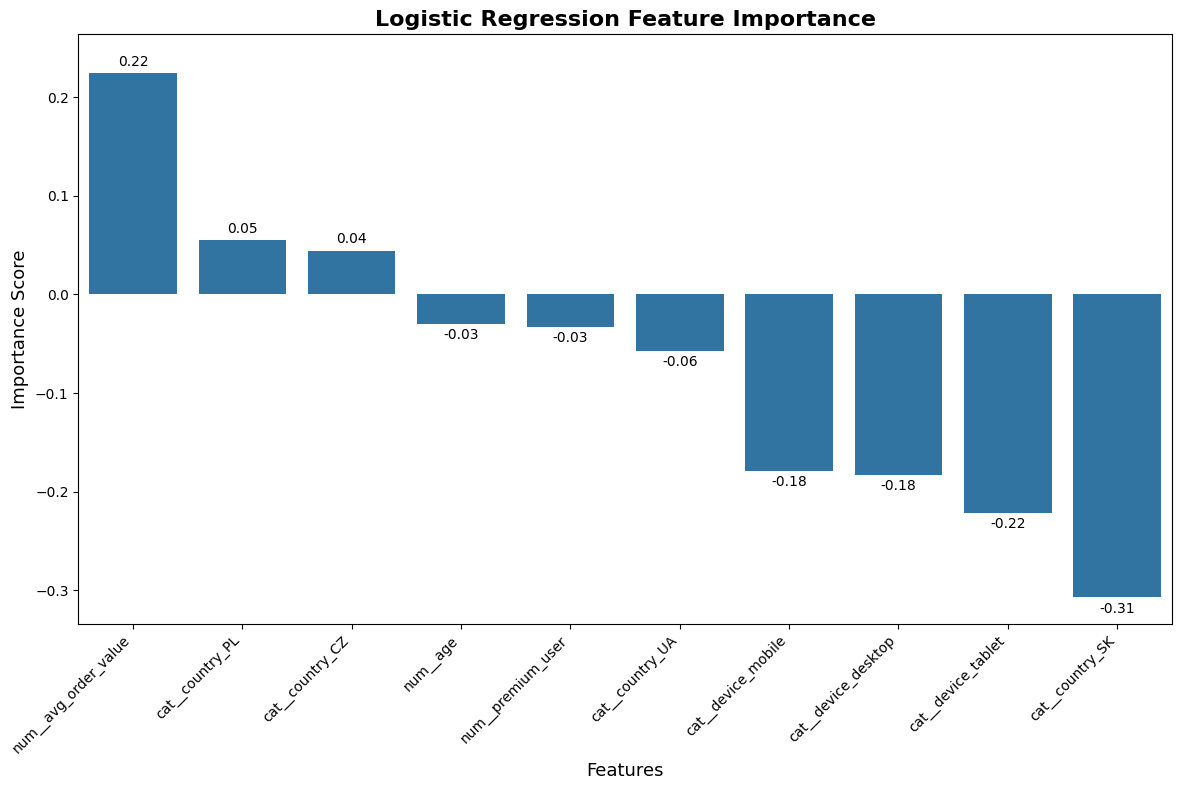

In [31]:
plt.figure(figsize = (12, 8))

lg_model = lg_pipeline.named_steps['model']
feature_names = lg_pipeline.named_steps['preprocessor'].get_feature_names_out()

lg_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': lg_model.coef_[0]
}).sort_values(by= 'importance', ascending = False)

ax = sns.barplot(data = lg_importance.head(10), x= 'feature', y= 'importance')
for container in ax.containers:
    ax.bar_label(container, fmt= '%.2f', padding= 3)

y_min, y_max = ax.get_ylim()
ax.set_ylim(y_min, y_max * 1.05)

plt.title("Logistic Regression Feature Importance", fontsize=16, fontweight="bold")
plt.xlabel("Features", fontsize=13)
plt.ylabel("Importance Score", fontsize=13)
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

# Random Forest Classifier feature importance

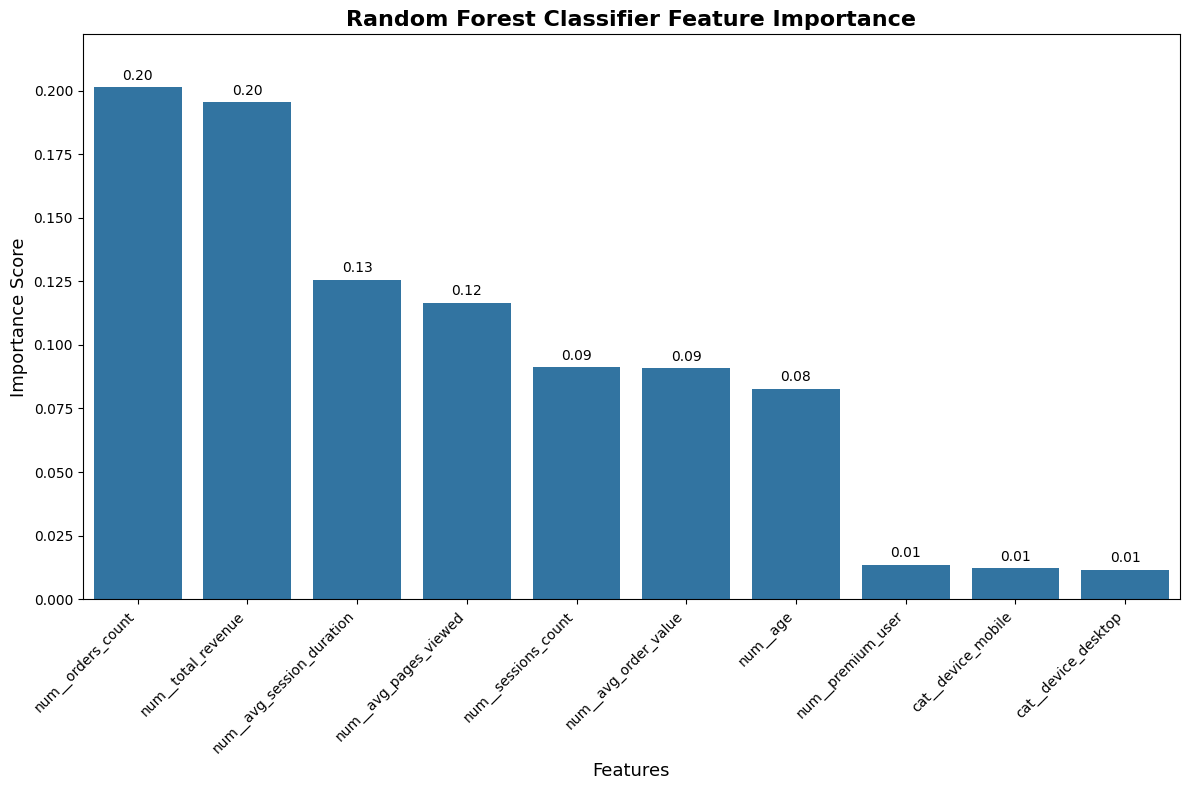

In [32]:
plt.figure(figsize = (12, 8))

rf_model = rf_pipeline.named_steps['model']
feature_names = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()

rf_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_model.feature_importances_
}).sort_values(by= 'importance', ascending = False)

ax = sns.barplot(data = rf_importance.head(10), x= 'feature', y= 'importance')
for container in ax.containers:
    ax.bar_label(container, fmt= '%.2f', padding= 3)

y_min, y_max = ax.get_ylim()
ax.set_ylim(y_min, y_max * 1.05)

plt.title("Random Forest Classifier Feature Importance", fontsize=16, fontweight="bold")
plt.xlabel("Features", fontsize=13)
plt.ylabel("Importance Score", fontsize=13)
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

# Compare Features

In [33]:
lg_top_10 = lg_importance['feature'].head(10).tolist()
rf_top_10 = rf_importance['feature'].head(10).tolist()

print("Logistic Regression Top 10 Features:\n", lg_top_10)
print("---------------------------------------------------")
print("Random Forest Classifier Top 10 Features:\n", rf_top_10)

Logistic Regression Top 10 Features:
 ['num__avg_order_value', 'cat__country_PL', 'cat__country_CZ', 'num__age', 'num__premium_user', 'cat__country_UA', 'cat__device_mobile', 'cat__device_desktop', 'cat__device_tablet', 'cat__country_SK']
---------------------------------------------------
Random Forest Classifier Top 10 Features:
 ['num__orders_count', 'num__total_revenue', 'num__avg_session_duration', 'num__avg_pages_viewed', 'num__sessions_count', 'num__avg_order_value', 'num__age', 'num__premium_user', 'cat__device_mobile', 'cat__device_desktop']


# Task 13. VarianceThreshold

In [34]:
selector = VarianceThreshold(threshold=0.01).fit(X_train[num_cols])
selected_features = X_train[num_cols].columns[selector.get_support()]

feature_variance = pd.DataFrame({ 
    "feature": X_train[num_cols].columns, 
    "variance": selector.variances_ 
}).sort_values(by = "variance", ascending = False) 

print("Original features:", len(X_train[num_cols].columns)) 
print("Selected features:", len(selected_features)) 
print(selected_features.tolist())
feature_variance

Original features: 8
Selected features: 8
['age', 'premium_user', 'orders_count', 'total_revenue', 'avg_order_value', 'sessions_count', 'avg_session_duration', 'avg_pages_viewed']


,feature,variance
3,total_revenue,69440.943564
4,avg_order_value,404.220975
0,age,232.724898
5,sessions_count,23.460589
2,orders_count,7.981704
6,avg_session_duration,6.150518
7,avg_pages_viewed,0.222960
1,premium_user,0.200271


# Task 14. Mutual Information

In [35]:
selector = SelectKBest(score_func= mutual_info_classif).fit(X_train[num_cols], y_train)

feature_score = pd.DataFrame({
    "feature": X_train[num_cols].columns,
    "score": selector.scores_
}).sort_values(by = "score", ascending = False).query("score > 0")
print("Original features:", len(X_train[num_cols].columns))
print("Selected features:", len(feature_score['feature']))
print(selected_features.tolist())
feature_score

E:\Python\.venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:782: UserWarning: k=10 is greater than n_features=8. All the features will be returned.
  warnings.warn(


Original features: 8
Selected features: 7
['age', 'premium_user', 'orders_count', 'total_revenue', 'avg_order_value', 'sessions_count', 'avg_session_duration', 'avg_pages_viewed']


,feature,score
2,orders_count,0.125307
3,total_revenue,0.117331
7,avg_pages_viewed,0.022983
6,avg_session_duration,0.018954
5,sessions_count,0.016270
4,avg_order_value,0.010892
0,age,0.000084


# Task 15. RFE

In [36]:
preprocessor = lg_pipeline.named_steps['preprocessor']

X_train_processed = pd.DataFrame(
    preprocessor.transform(X_train),
    columns= feature_names,
    index= X_train.index
)

X_test_processed = pd.DataFrame(
    preprocessor.transform(X_test),
    columns= feature_names,
    index= X_test.index
)

selector = RFE(estimator = lg_model, n_features_to_select=10).fit(X_train_processed, y_train)
selected_features = feature_names[selector.get_support()]
print("Top 10 features:\n", selected_features)

Top 10 features:
 ['num__orders_count' 'num__total_revenue' 'num__avg_order_value'
 'num__sessions_count' 'num__avg_session_duration' 'num__avg_pages_viewed'
 'cat__country_HU' 'cat__country_SK' 'cat__device_desktop'
 'cat__device_tablet']


# Task 16. Permutation Importance

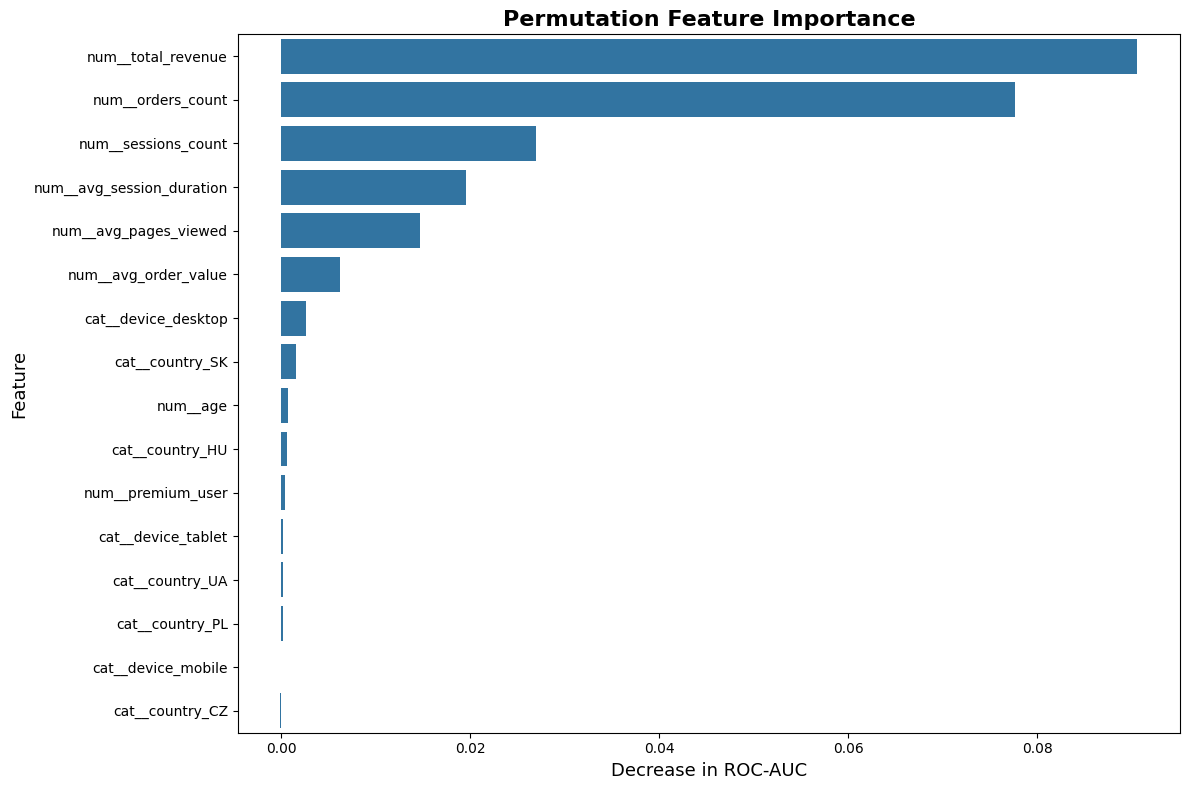

In [37]:
plt.figure(figsize = (12, 8))
perm = permutation_importance(lg_model, X_test_processed.values, y_test, scoring = "roc_auc", n_repeats = 20, random_state= 42)

perm_df = pd.DataFrame({
    "feature": feature_names,
    "importance": perm.importances_mean
}).sort_values(by= 'importance', ascending = False)

sns.barplot(data= perm_df, x= "importance", y= "feature")

plt.title("Permutation Feature Importance", fontsize=16, fontweight="bold")

plt.xlabel("Decrease in ROC-AUC", fontsize=13)
plt.ylabel("Feature", fontsize=13)

plt.tight_layout()
plt.show()

# Block 6. Feature Engineering

# Task 17. Behavioral Feature Engineering

# Create average duration per page feature

In [38]:
df['avg_duration_per_page'] = np.where(df['avg_pages_viewed'] > 0, df['avg_session_duration'] / df['avg_pages_viewed'], 0).round(2)

# Create average number of sessions per order feature

In [39]:
df['avg_sessions_per_order'] = np.where(df['orders_count'] > 0, df['sessions_count'] / df['orders_count'], 0).round(2)

# Create average revenue per session feature

In [40]:
df['avg_revenue_per_session'] = np.where(df['sessions_count'] > 0, df['total_revenue'] / df['sessions_count'], 0).round(2)

# Create average number of orders per session feature

In [41]:
df['avg_orders_per_session'] = np.where(df['sessions_count'] > 0, df['orders_count'] / df['sessions_count'], 0).round(2)

# Task 18. Correlation Analysis

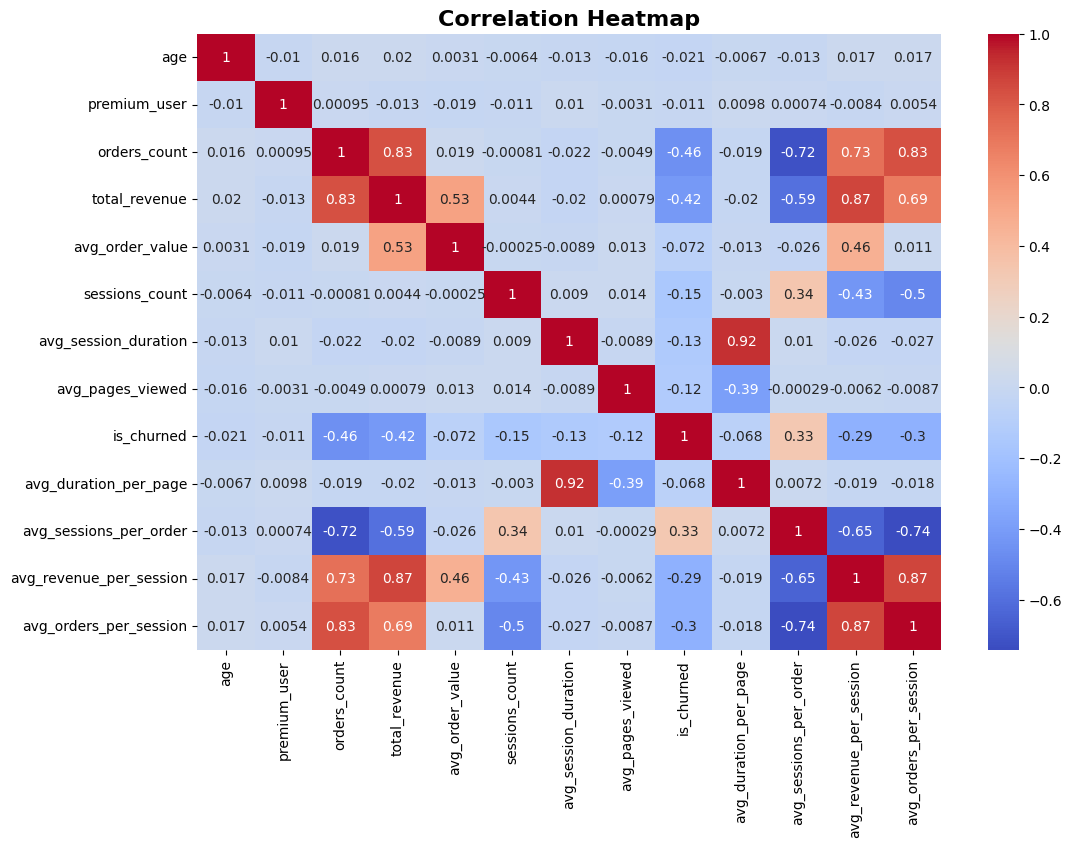

In [42]:
plt.figure(figsize = (12, 8))
data = df.drop(columns= 'customer_id').select_dtypes(include = 'number').corr()
sns.heatmap(data, cmap = 'coolwarm', annot= True)
plt.title("Correlation Heatmap", fontsize=16, fontweight="bold")

plt.show()

# Block 7. Feature Selection + Final Baseline

# Task 19. Train Models with Selected Features

In [43]:
X_selected = df[['orders_count', 'total_revenue', 'avg_order_value', 'sessions_count', 'avg_session_duration', 
                'avg_pages_viewed', 'age', 'country', 'device', 'premium_user']]
y = df['is_churned']

num_cols_selected = X_selected.select_dtypes(include= 'number').columns
cat_cols_selected = X_selected.select_dtypes(exclude= 'number').columns
X_train_selected, X_test_selected, y_train_selected, y_test_selected = train_test_split(X_selected, y, test_size = 0.2, stratify = y)

preprocessor_selected = ColumnTransformer([
    ('num', StandardScaler(), num_cols_selected),
    ('cat', OneHotEncoder(), cat_cols_selected)
])

lg_pipeline_selected = Pipeline([
    ('preprocessor', preprocessor_selected),
    ('model', LogisticRegression(random_state= 42, max_iter= 1000))
]).fit(X_train_selected, y_train_selected)

rf_pipeline_selected = Pipeline([
    ('preprocessor', preprocessor_selected),
    ('model', RandomForestClassifier(random_state= 42))
]).fit(X_train_selected, y_train_selected)

# Evaluate models

In [44]:
pipelines = {"Logistic Regression(selected)": lg_pipeline_selected, "Random Forest(selected)": rf_pipeline_selected}
results = []
for name, pipeline in pipelines.items():
    pred = pipeline.predict(X_test_selected)
    proba = pipeline.predict_proba(X_test_selected)[:, 1]
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test_selected, pred),
        "Precision": precision_score(y_test_selected, pred),
        "Recall": recall_score(y_test_selected, pred),
        "F1": f1_score(y_test_selected, pred),
        "ROC-AUC": roc_auc_score(y_test_selected, proba)
    })
results_selected = pd.DataFrame(results)
results_selected

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression(selected),0.786,0.734266,0.603448,0.662461,0.841989
1,Random Forest(selected),0.779,0.708197,0.620690,0.661562,0.844933


# Task 20. Full Features vs Selected Features

# Full features

In [45]:
X_full = df.drop(columns= ['customer_id', 'is_churned'])
y = df['is_churned']

num_cols_full = X_full.select_dtypes(include= 'number').columns
cat_cols_full = X_full.select_dtypes(exclude= 'number').columns
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(X_full, y, test_size = 0.2, stratify = y)

preprocessor_full = ColumnTransformer([
    ('num', StandardScaler(), num_cols_full),
    ('cat', OneHotEncoder(), cat_cols_full)
])

lg_pipeline_full = Pipeline([
    ('preprocessor', preprocessor_full),
    ('model', LogisticRegression(random_state= 42, max_iter= 1000))
]).fit(X_train_full, y_train_full)

rf_pipeline_full = Pipeline([
    ('preprocessor', preprocessor_full),
    ('model', RandomForestClassifier(random_state= 42))
]).fit(X_train_full, y_train_full)

# Evaluate models

In [46]:
pipelines = {"Logistic Regression(full)": lg_pipeline_full, "Random Forest(full)": rf_pipeline_full}
results = []
for name, pipeline in pipelines.items():
    pred = pipeline.predict(X_test_full)
    proba = pipeline.predict_proba(X_test_full)[:, 1]
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test_full, pred),
        "Precision": precision_score(y_test_full, pred),
        "Recall": recall_score(y_test_full, pred),
        "F1": f1_score(y_test_full, pred),
        "ROC-AUC": roc_auc_score(y_test_full, proba)
    })
results_full = pd.DataFrame(results)
results_full

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression(full),0.782,0.728873,0.594828,0.655063,0.827366
1,Random Forest(full),0.796,0.735294,0.646552,0.688073,0.859010


# Compare Full Features and Selected Features

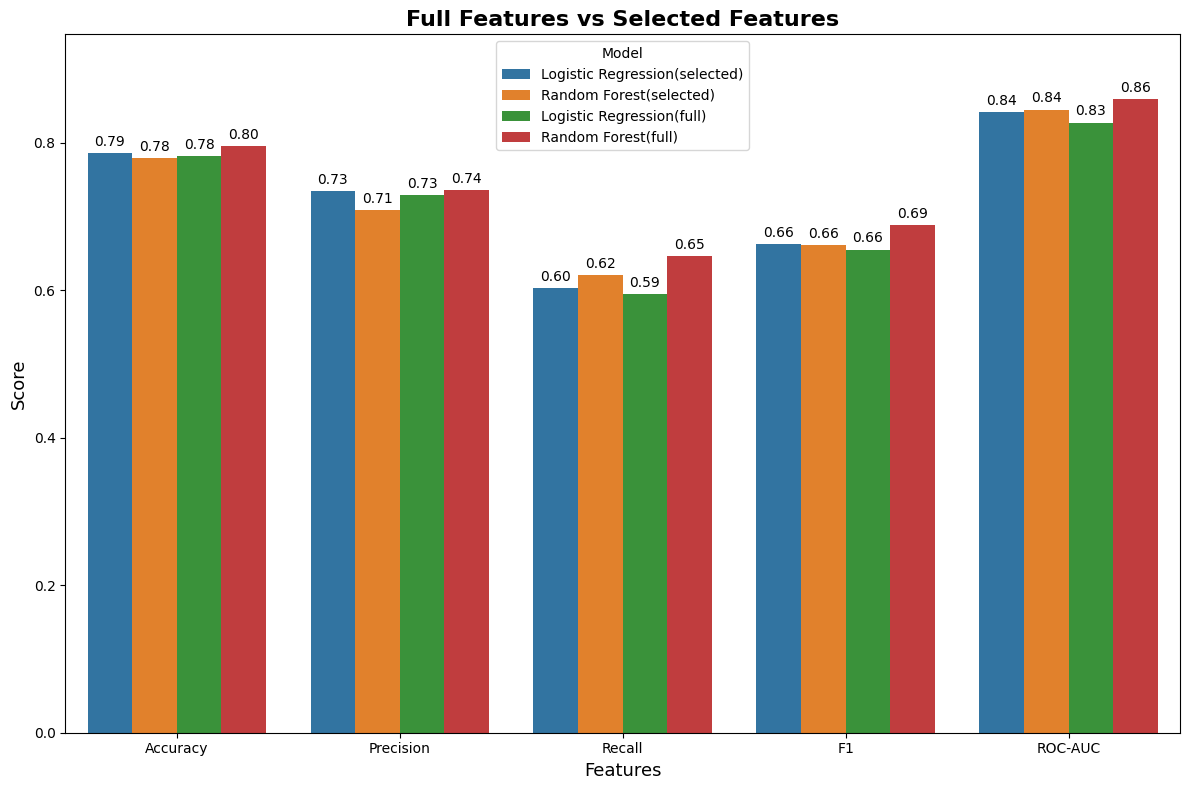

In [47]:
plt.figure(figsize= (12, 8))
df_all = pd.concat([results_selected, results_full], ignore_index=True)
results_melted = df_all.melt(id_vars='Model', var_name='Metric', value_name='Score')

ax = sns.barplot(data= results_melted, x= 'Metric', y= 'Score', hue= 'Model')
for container in ax.containers:
    ax.bar_label(container, fmt= '%.2f', padding= 3)

y_min, y_max = ax.get_ylim()
ax.set_ylim(y_min, y_max * 1.05)

plt.title("Full Features vs Selected Features", fontsize=16, fontweight="bold")
plt.xlabel("Features", fontsize=13)
plt.ylabel("Score", fontsize=13)

plt.tight_layout()
plt.show()

# Block 8. Explainability

# Task 20. SHAP Explainer

In [48]:
explainer = shap.Explainer(rf_model)
shap_values = explainer(X_test_processed)
print(shap_values)

.values =
array([[[-2.61942519e-02,  2.61942519e-02],
        [-1.45647678e-05,  1.45647678e-05],
        [ 1.31714520e-01, -1.31714520e-01],
        ...,
        [-1.27332602e-03,  1.27332602e-03],
        [-3.52488245e-03,  3.52488245e-03],
        [-2.79178500e-04,  2.79178500e-04]],

       [[ 4.92544336e-03, -4.92544336e-03],
        [ 1.53067407e-03, -1.53067407e-03],
        [ 1.05193274e-01, -1.05193274e-01],
        ...,
        [ 2.04873480e-04, -2.04873480e-04],
        [-3.75841062e-04,  3.75841062e-04],
        [ 1.84113667e-03, -1.84113667e-03]],

       [[-1.08819964e-02,  1.08819964e-02],
        [ 6.99976140e-03, -6.99976140e-03],
        [ 1.31087038e-01, -1.31087038e-01],
        ...,
        [ 5.98932943e-03, -5.98932943e-03],
        [ 1.05096517e-02, -1.05096517e-02],
        [ 8.50674496e-04, -8.50674496e-04]],

       ...,

       [[-6.76258104e-03,  6.76258104e-03],
        [ 2.15854891e-03, -2.15854891e-03],
        [-2.14895572e-01,  2.14895572e-01],
        

# Task 21. SHAP Summary Plot

<Figure size 1200x800 with 0 Axes>

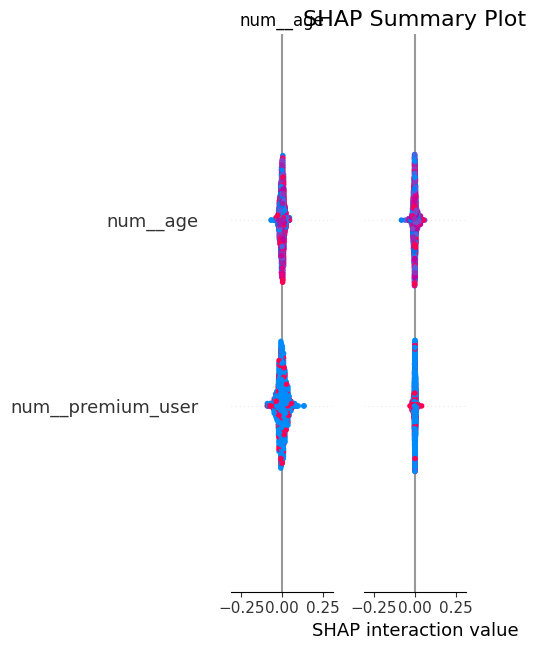

In [49]:
plt.figure(figsize = (12, 8))
shap.summary_plot(shap_values, show= False, feature_names= feature_names)

plt.title("SHAP Summary Plot", fontsize=16)
plt.tight_layout()
plt.show()

# Task 22. SHAP Bar Plot

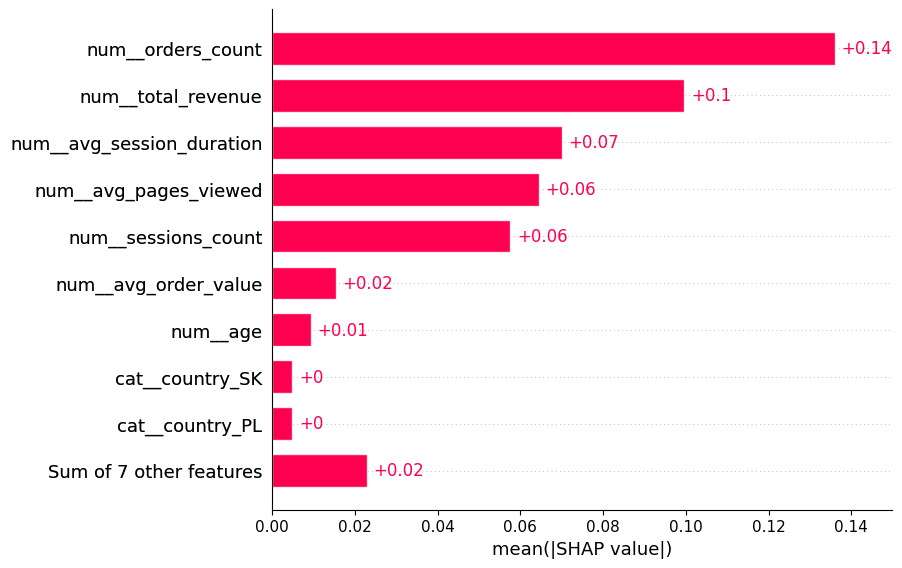

In [50]:
shap.plots.bar(shap_values[:, :, 1])

# Task 23. SHAP Dependence Plot

<Figure size 1200x800 with 0 Axes>

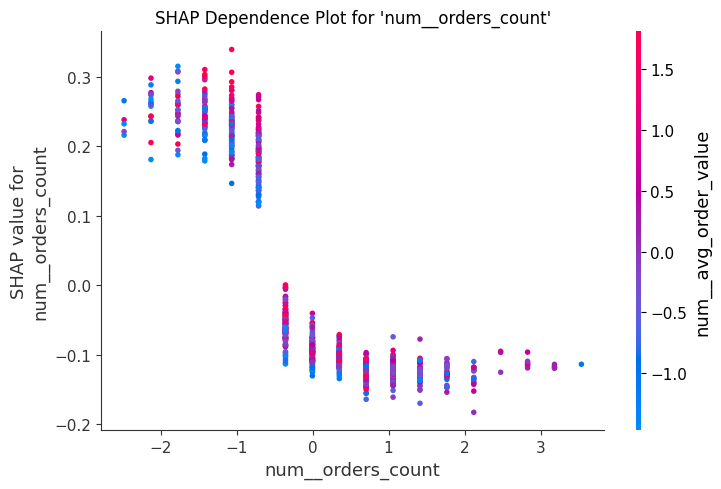

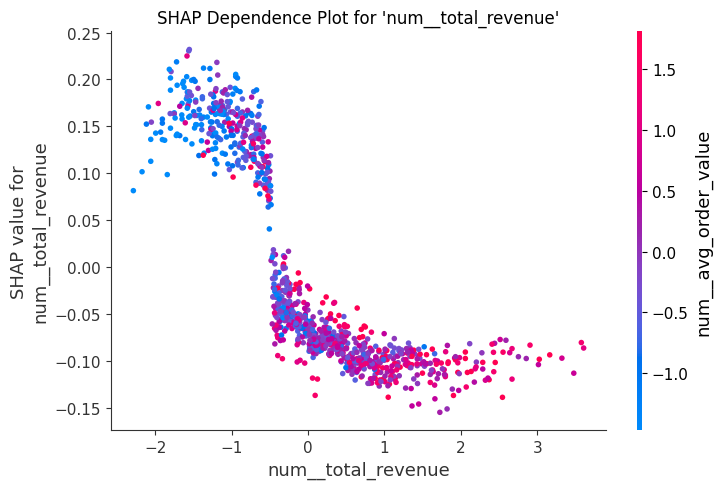

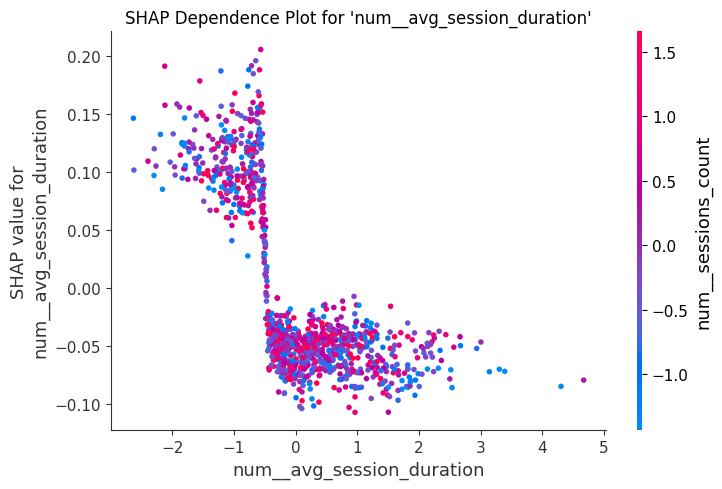

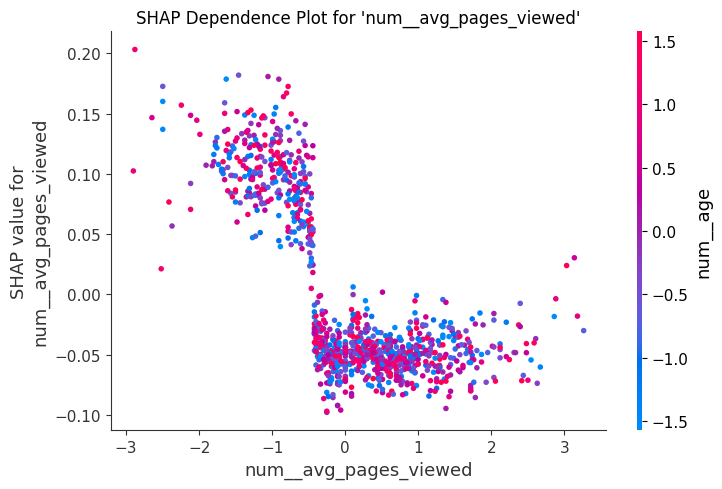

In [51]:
plt.figure(figsize = (12, 8))
top_features = rf_importance["feature"].head(4)
for feature in top_features:
    shap.dependence_plot(feature, shap_values[:, :, 1].values, X_test_processed, show = False)

    plt.title(f"SHAP Dependence Plot for '{feature}'")
    plt.tight_layout()
    plt.show()

# Task 24. Partial Dependence Plot

E:\Python\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
E:\Python\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
E:\Python\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
E:\Python\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
E:\Python\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
E:\Python\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but

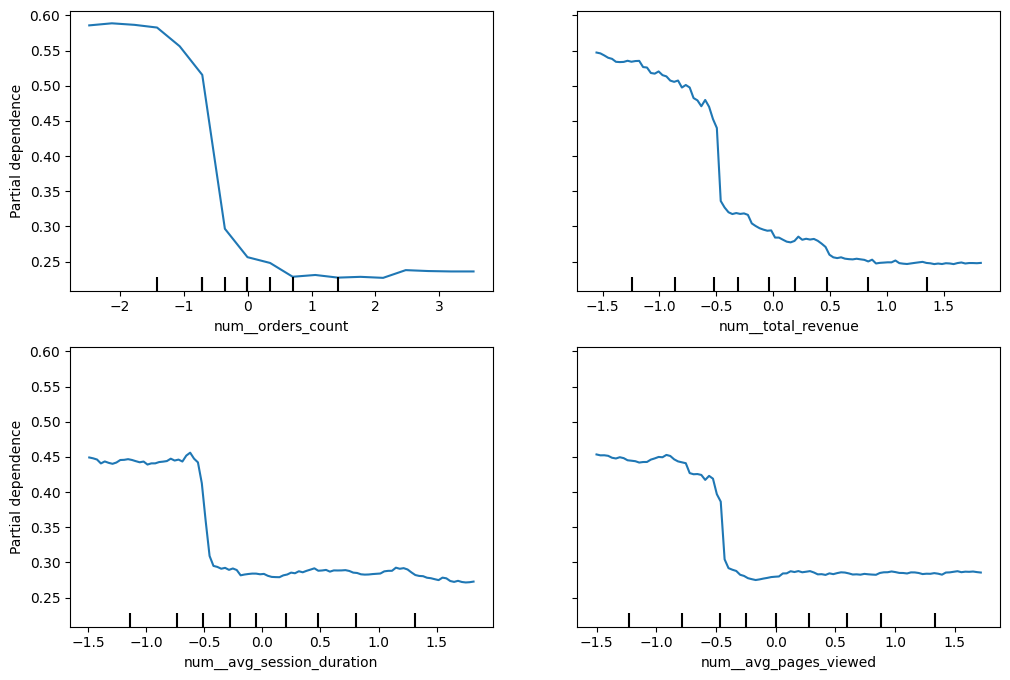

In [52]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
PartialDependenceDisplay.from_estimator(estimator= rf_model, X= X_test_processed, features= rf_importance['feature'].head(4).values, ax= ax)

# Block 9. Error Analysis

# Task 25. Confusion Matrix

# Logistic Regression(Baseline vs Selected vs Full)

In [53]:
lg_pred = lg_pipeline.predict(X_test)
lg_pred_selected = lg_pipeline_selected.predict(X_test_selected)
lg_pred_full = lg_pipeline_full.predict(X_test_full)

lg_cm = confusion_matrix(y_test, lg_pred)
lg_cm_selected = confusion_matrix(y_test_selected, lg_pred_selected)
lg_cm_full = confusion_matrix(y_test_full, lg_pred_full)

print("Baseline Logistic Regression:\n", lg_cm)
print("Logistic Regression with selected features:\n", lg_cm_selected)
print("Logistic Regression with full features:\n", lg_cm_full)

Baseline Logistic Regression:
 [[571  81]
 [150 198]]
Logistic Regression with selected features:
 [[576  76]
 [138 210]]
Logistic Regression with full features:
 [[575  77]
 [141 207]]


# Random Forest Classifier(Baseline vs Selected vs Full)

In [54]:
rf_pred = rf_pipeline.predict(X_test)
rf_pred_selected = rf_pipeline_selected.predict(X_test_selected)
rf_pred_full = rf_pipeline_full.predict(X_test_full)

rf_cm = confusion_matrix(y_test, rf_pred)
rf_cm_selected = confusion_matrix(y_test_selected, rf_pred_selected)
rf_cm_full = confusion_matrix(y_test_full, rf_pred_full)

print("Baseline Random Forest Classifier:\n", rf_cm) 
print("Random Forest Classifier with selected features:\n", rf_cm_selected)
print("Random Forest Classifier with full features:\n", rf_cm_full)

Baseline Random Forest Classifier:
 [[559  93]
 [140 208]]
Random Forest Classifier with selected features:
 [[563  89]
 [132 216]]
Random Forest Classifier with full features:
 [[571  81]
 [123 225]]


# Task 26. Classification Report

# Logistic Regression(Baseline vs Selected vs Full)

In [55]:
lg_cr = classification_report(y_test, lg_pred, digits= 3, target_names=['Active', 'Churn'])
lg_cr_selected = classification_report(y_test_selected, lg_pred_selected, digits= 3, target_names=['Active', 'Churn'])
lg_cr_full = classification_report(y_test_full, lg_pred_full, digits= 3, target_names=['Active', 'Churn'])

print("Baseline Logistic Regression:\n", lg_cr)
print("Logistic Regression with selected features:\n", lg_cr_selected)
print("Logistic Regression with full features:\n", lg_cr_full)

Baseline Logistic Regression:
               precision    recall  f1-score   support

      Active      0.792     0.876     0.832       652
       Churn      0.710     0.569     0.632       348

    accuracy                          0.769      1000
   macro avg      0.751     0.722     0.732      1000
weighted avg      0.763     0.769     0.762      1000

Logistic Regression with selected features:
               precision    recall  f1-score   support

      Active      0.807     0.883     0.843       652
       Churn      0.734     0.603     0.662       348

    accuracy                          0.786      1000
   macro avg      0.770     0.743     0.753      1000
weighted avg      0.782     0.786     0.780      1000

Logistic Regression with full features:
               precision    recall  f1-score   support

      Active      0.803     0.882     0.841       652
       Churn      0.729     0.595     0.655       348

    accuracy                          0.782      1000
   macro av

# Random Forest Classifier(Baseline vs Selected vs Full)

In [56]:
rf_cr = classification_report(y_test, rf_pred, digits= 3, target_names=['Active', 'Churn'])
rf_cr_selected = classification_report(y_test_selected, rf_pred_selected, digits= 3, target_names=['Active', 'Churn'])
rf_cr_full = classification_report(y_test_full, rf_pred_full, digits= 3, target_names=['Active', 'Churn'])

print("Baseline Random Forest Classifier:\n", rf_cr) 
print("Random Forest Classifier with selected features:\n", rf_cr_selected)
print("Random Forest Classifier with full features:\n", rf_cr_full)

Baseline Random Forest Classifier:
               precision    recall  f1-score   support

      Active      0.800     0.857     0.828       652
       Churn      0.691     0.598     0.641       348

    accuracy                          0.767      1000
   macro avg      0.745     0.728     0.734      1000
weighted avg      0.762     0.767     0.763      1000

Random Forest Classifier with selected features:
               precision    recall  f1-score   support

      Active      0.810     0.863     0.836       652
       Churn      0.708     0.621     0.662       348

    accuracy                          0.779      1000
   macro avg      0.759     0.742     0.749      1000
weighted avg      0.775     0.779     0.775      1000

Random Forest Classifier with full features:
               precision    recall  f1-score   support

      Active      0.823     0.876     0.848       652
       Churn      0.735     0.647     0.688       348

    accuracy                          0.796      1

# Task 27. Find Incorrect Predictions

# Logistic Regression(Baseline)

In [57]:
lg_proba = lg_pipeline.predict_proba(X_test)[:, 1]
lg_error_mask = lg_pred != y_test
lg_incorrect_predictions = X_test.loc[lg_error_mask].copy()
lg_incorrect_predictions['actual'] = y_test.loc[lg_error_mask]
lg_incorrect_predictions['predicted'] = lg_pred[lg_error_mask]
lg_incorrect_predictions['churn_probability'] = lg_proba[lg_error_mask]
lg_incorrect_predictions['error_type'] = np.where(
    (lg_incorrect_predictions['actual'] == 0) &
    (lg_incorrect_predictions['predicted'] == 1),
    'False Positive',
    'False Negative'
)
lg_incorrect_predictions = lg_incorrect_predictions.sort_values(by= 'churn_probability', ascending=False)
print(lg_incorrect_predictions)

      customer_id country  age   device  premium_user  orders_count  \
74           2711      PL   27   mobile             0             2   
338          4169      CZ   51   tablet             1             2   
70           4500      HU   57  desktop             0             3   
190          2635      PL   62   mobile             0             3   
2661         4584      UA   45   mobile             1             7   
...           ...     ...  ...      ...           ...           ...   
4983         2154      PL   40   mobile             1            12   
4372         2091      PL   28  desktop             0            12   
4481         3129      HU   23   mobile             0            13   
4932         3372      UA   42   mobile             0            14   
4946         2035      CZ   33  desktop             0            16   

      total_revenue  avg_order_value  sessions_count  avg_session_duration  \
74              141               71              27                 

# Logistic Regression(Selected)

In [58]:
lg_proba_selected = lg_pipeline_selected.predict_proba(X_test_selected)[:, 1]
lg_error_mask_selected = lg_pred_selected != y_test_selected
lg_incorrect_predictions_selected = X_test_selected.loc[lg_error_mask_selected].copy()
lg_incorrect_predictions_selected['actual'] = (y_test_selected.loc[lg_error_mask_selected])
lg_incorrect_predictions_selected['predicted'] = (lg_pred_selected[lg_error_mask_selected])
lg_incorrect_predictions_selected['churn_probability'] = (lg_proba_selected[lg_error_mask_selected])
lg_incorrect_predictions_selected['error_type'] = np.where(
    (lg_incorrect_predictions_selected['actual'] == 0) &
    (lg_incorrect_predictions_selected['predicted'] == 1),
    'False Positive',
    'False Negative'
)
lg_incorrect_predictions_selected = (lg_incorrect_predictions_selected.sort_values(by= 'churn_probability', ascending=False))
print(lg_incorrect_predictions_selected)

      orders_count  total_revenue  avg_order_value  sessions_count  \
6                1             41               41              26   
212              3            208               69              25   
1013             4            388               97              22   
951              4            379               95              22   
2661             7            612               87              13   
...            ...            ...              ...             ...   
4776            12           1116               93              18   
4960            13           1342              103              21   
4372            12            928               77              34   
3902            10            809               81              42   
4946            16           1296               81              21   

      avg_session_duration  avg_pages_viewed  age country   device  \
6                    11.87              5.50   27      CZ   mobile   
212                

# Logistic Regression(Full)

In [59]:
lg_proba_full = lg_pipeline_full.predict_proba(X_test_full)[:, 1]
lg_error_mask_full = lg_pred_full != y_test_full
lg_incorrect_predictions_full = X_test_full.loc[lg_error_mask_full].copy()
lg_incorrect_predictions_full['actual'] = (y_test_full.loc[lg_error_mask_full])
lg_incorrect_predictions_full['predicted'] = (lg_pred_full[lg_error_mask_full])
lg_incorrect_predictions_full['churn_probability'] = (lg_proba_full[lg_error_mask_full])
lg_incorrect_predictions_full['error_type'] = np.where(
    (lg_incorrect_predictions_full['actual'] == 0) &
    (lg_incorrect_predictions_full['predicted'] == 1),
    'False Positive',
    'False Negative'
)
lg_incorrect_predictions_full = (lg_incorrect_predictions_full.sort_values(by= 'churn_probability', ascending=False))
print(lg_incorrect_predictions_full)

     country  age   device  premium_user  orders_count  total_revenue  \
6         CZ   27   mobile             1             1             41   
52        SK   49  desktop             0             2            124   
34        UA   70  desktop             0             2            108   
124       UA   61   tablet             0             3            177   
43        UA   34  desktop             0             3            116   
...      ...  ...      ...           ...           ...            ...   
4747      SK   50   mobile             1            12           1093   
4870      UA   69   tablet             0            10           1191   
4512      PL   65  desktop             1            10            980   
4623      UA   39   mobile             1            15           1020   
4778      UA   55   tablet             1             9           1117   

      avg_order_value  sessions_count  avg_session_duration  avg_pages_viewed  \
6                  41              26     

# Random Forest Classifier(Baseline)

In [60]:
rf_proba = rf_pipeline.predict_proba(X_test)[:, 1]
rf_error_mask = rf_pred != y_test
rf_incorrect_predictions = X_test.loc[rf_error_mask].copy()
rf_incorrect_predictions['actual'] = (y_test.loc[rf_error_mask])
rf_incorrect_predictions['predicted'] = (rf_pred[rf_error_mask])
rf_incorrect_predictions['churn_probability'] = (rf_proba[rf_error_mask])
rf_incorrect_predictions['error_type'] = np.where(
    (rf_incorrect_predictions['actual'] == 0) &
    (rf_incorrect_predictions['predicted'] == 1),
    'False Positive',
    'False Negative'
)
rf_incorrect_predictions = (rf_incorrect_predictions.sort_values(by= 'churn_probability', ascending=False))
print(rf_incorrect_predictions)

      customer_id country  age   device  premium_user  orders_count  \
411          3496      PL   55   mobile             0             5   
301          1074      UA   48   mobile             0             5   
74           2711      PL   27   mobile             0             2   
601          4176      CZ   67   mobile             0             4   
104          4810      UA   63   mobile             0             5   
...           ...     ...  ...      ...           ...           ...   
3709          737      SK   45   mobile             0            11   
4687         4227      UA   30   tablet             0            11   
4193          771      UA   34  desktop             0             9   
3039         4750      UA   59  desktop             0             8   
4547         2417      UA   24   mobile             0            11   

      total_revenue  avg_order_value  sessions_count  avg_session_duration  \
411             275               55              26                 

# Random Forest Classifier(Selected)

In [61]:
rf_proba_selected = rf_pipeline_selected.predict_proba( X_test_selected)[:, 1]
rf_error_mask_selected = rf_pred_selected != y_test_selected
rf_incorrect_predictions_selected = X_test_selected.loc[rf_error_mask_selected].copy()
rf_incorrect_predictions_selected['actual'] = (y_test_selected.loc[rf_error_mask_selected])
rf_incorrect_predictions_selected['predicted'] = (rf_pred_selected[rf_error_mask_selected])
rf_incorrect_predictions_selected['churn_probability'] = (rf_proba_selected[rf_error_mask_selected])
rf_incorrect_predictions_selected['error_type'] = np.where(
    (rf_incorrect_predictions_selected['actual'] == 0) &
    (rf_incorrect_predictions_selected['predicted'] == 1),
    'False Positive',
    'False Negative'
)
rf_incorrect_predictions_selected = (rf_incorrect_predictions_selected.sort_values(by= 'churn_probability', ascending=False))
print(rf_incorrect_predictions_selected)

      orders_count  total_revenue  avg_order_value  sessions_count  \
1013             4            388               97              22   
104              5            162               32              24   
411              5            275               55              26   
951              4            379               95              22   
6                1             41               41              26   
...            ...            ...              ...             ...   
3537             9            740               82              21   
1774             7            497               71              25   
2299             7            559               80              29   
4443            11            950               86              24   
3709            11            772               70              21   

      avg_session_duration  avg_pages_viewed  age country   device  \
1013                 12.02              5.68   35      PL   mobile   
104                

# Random Forest Classifier(Full)

In [62]:
rf_proba_full = rf_pipeline_full.predict_proba(X_test_full)[:, 1]
rf_error_mask_full = rf_pred_full != y_test_full
rf_incorrect_predictions_full = X_test_full.loc[rf_error_mask_full].copy()
rf_incorrect_predictions_full['actual'] = (y_test_full.loc[rf_error_mask_full])
rf_incorrect_predictions_full['predicted'] = (rf_pred_full[rf_error_mask_full])
rf_incorrect_predictions_full['churn_probability'] = (rf_proba_full[rf_error_mask_full])
rf_incorrect_predictions_full['error_type'] = np.where(
    (rf_incorrect_predictions_full['actual'] == 0) &
    (rf_incorrect_predictions_full['predicted'] == 1),
    'False Positive',
    'False Negative'
)
rf_incorrect_predictions_full = (rf_incorrect_predictions_full.sort_values(by= 'churn_probability', ascending=False))
print(rf_incorrect_predictions_full)

     country  age   device  premium_user  orders_count  total_revenue  \
603       UA   19  desktop             0             4            314   
504       SK   27   mobile             1             4            294   
6         CZ   27   mobile             1             1             41   
339       SK   30   mobile             0             6            253   
34        UA   70  desktop             0             2            108   
...      ...  ...      ...           ...           ...            ...   
3718      SK   61  desktop             0             9            774   
4623      UA   39   mobile             1            15           1020   
4629      CZ   27  desktop             0             9           1022   
4547      UA   24   mobile             0            11            994   
3273      PL   29   mobile             0             8            700   

      avg_order_value  sessions_count  avg_session_duration  avg_pages_viewed  \
603                79              30     

# Compare results

In [63]:
error_summary = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Logistic Regression Selected',
        'Logistic Regression Full',
        'Random Forest',
        'Random Forest Selected',
        'Random Forest Full'],
    
    'Incorrect Predictions': [
        len(lg_incorrect_predictions),
        len(lg_incorrect_predictions_selected),
        len(lg_incorrect_predictions_full),
        len(rf_incorrect_predictions),
        len(rf_incorrect_predictions_selected),
        len(rf_incorrect_predictions_full)]
})

error_summary['Error Rate (%)'] = (
    error_summary['Incorrect Predictions']
    / len(X_test)
    * 100)

print(error_summary)

                          Model  Incorrect Predictions  Error Rate (%)
0           Logistic Regression                    231            23.1
1  Logistic Regression Selected                    214            21.4
2      Logistic Regression Full                    218            21.8
3                 Random Forest                    233            23.3
4        Random Forest Selected                    221            22.1
5            Random Forest Full                    204            20.4


# Task 28. SHAP Waterfall Plot for Errors

In [64]:
def plot_shap_waterfall_for_errors(
    position,
    error_row,
    shap_values_churn,
    explainer,
    X_processed,
    feature_names
):
    if isinstance(explainer.expected_value, (list, np.ndarray)):
        base_value = explainer.expected_value[1]
    else:
        base_value = explainer.expected_value

    if hasattr(X_processed[position], "toarray"):
        feature_data = X_processed[position].toarray().flatten()
    else:
        feature_data = X_processed[position]

    explanation = shap.Explanation(
        values= shap_values_churn[position],
        base_values= base_value,
        data= feature_data,
        feature_names= feature_names
    )
    print("Actual:", error_row['actual'])
    print("Predicted:", error_row['predicted'])
    print("Churn probability:", round(error_row['churn_probability'], 3))
    print("Error type:", error_row['error_type'])

    shap.plots.waterfall(explanation, max_display=10)

# Logistic Regression(full)

shap:WARNING: Background dataset has 1000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1000 when initializing the masker.


Actual: 1
Predicted: 0
Churn probability: 0.499
Error type: False Negative


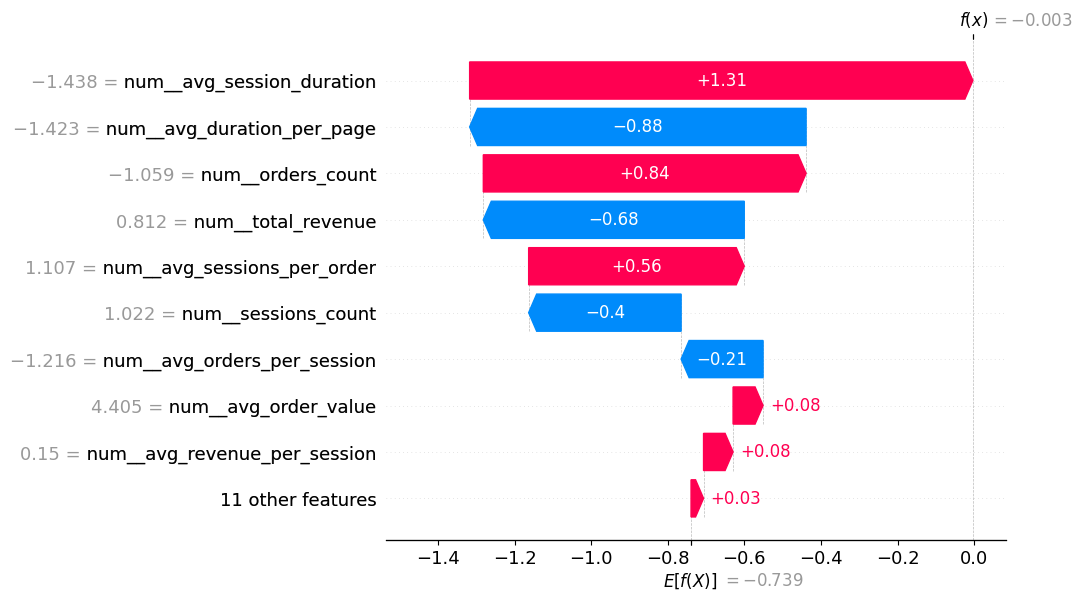

Actual: 1
Predicted: 0
Churn probability: 0.494
Error type: False Negative


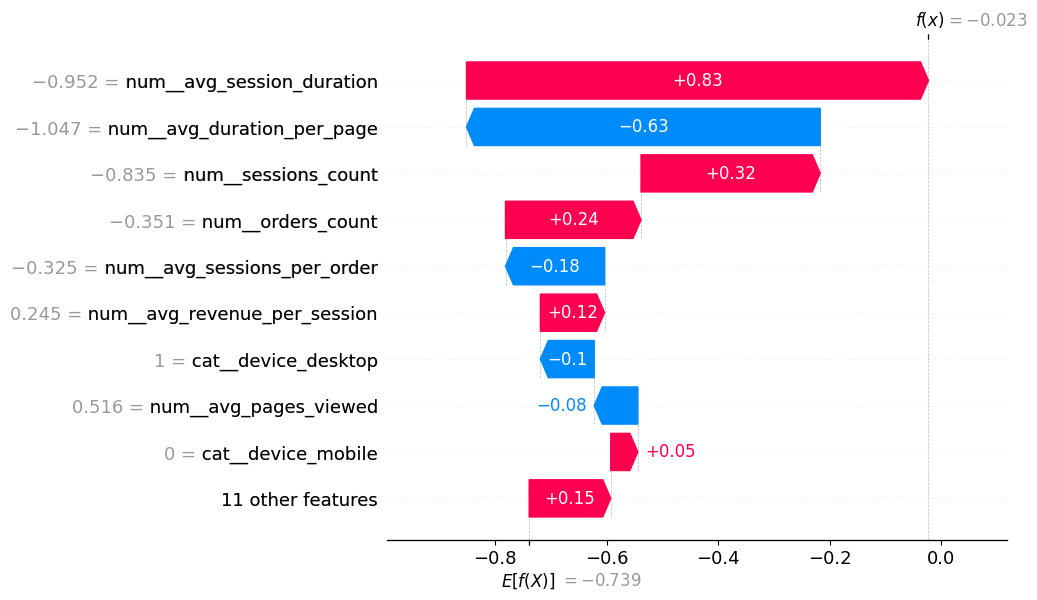

Actual: 1
Predicted: 0
Churn probability: 0.487
Error type: False Negative


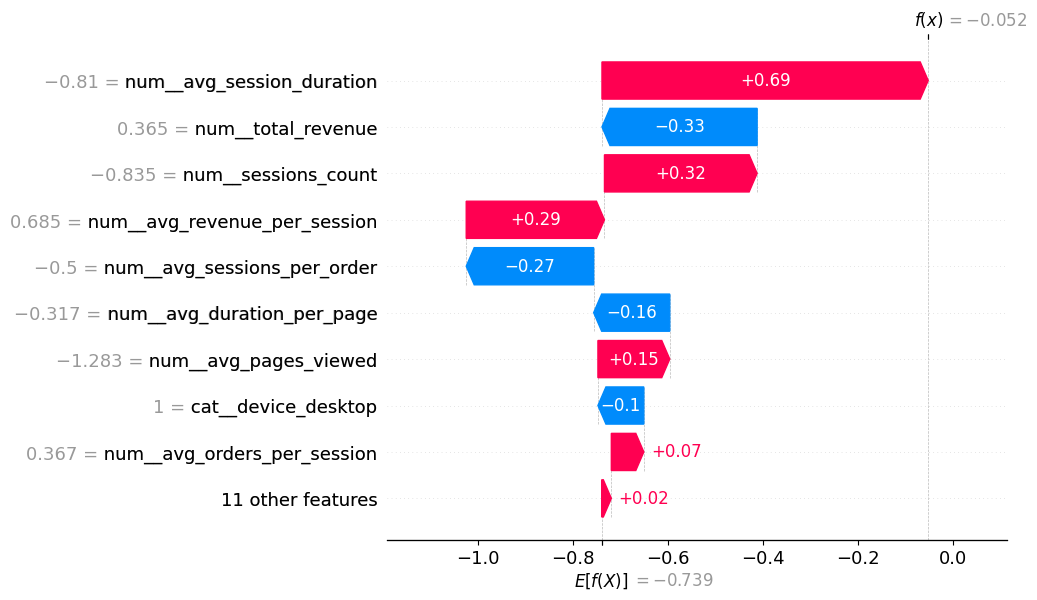

Actual: 0
Predicted: 1
Churn probability: 1.0
Error type: False Positive


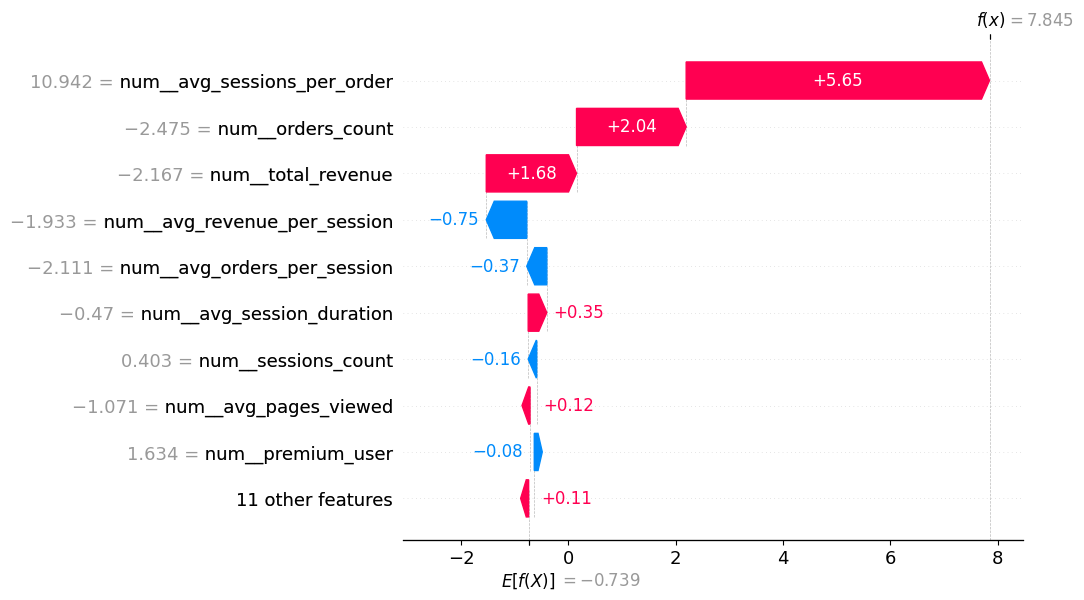

Actual: 0
Predicted: 1
Churn probability: 0.981
Error type: False Positive


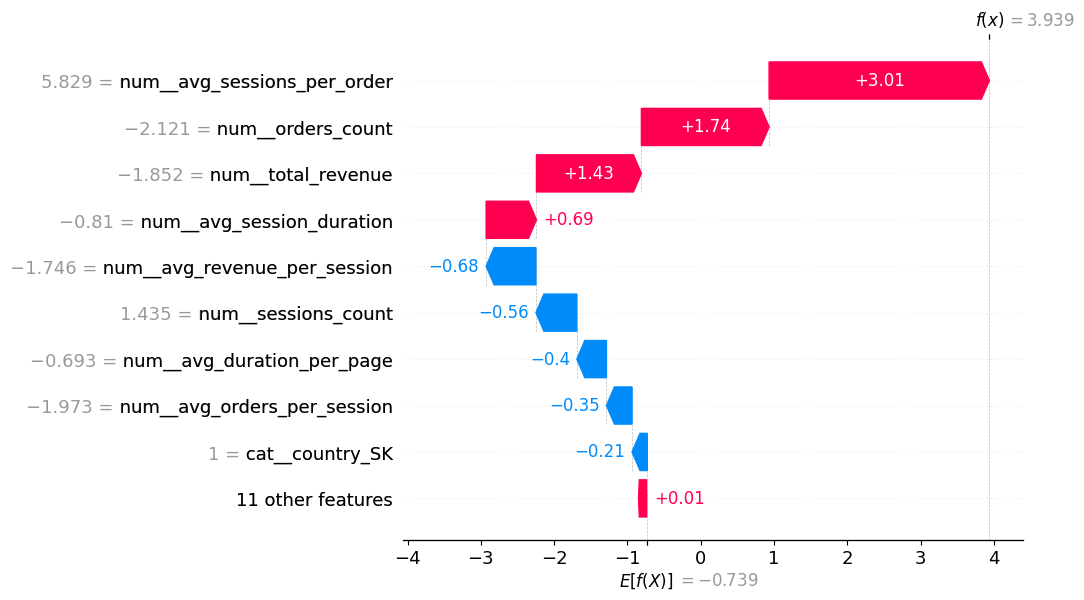

Actual: 0
Predicted: 1
Churn probability: 0.976
Error type: False Positive


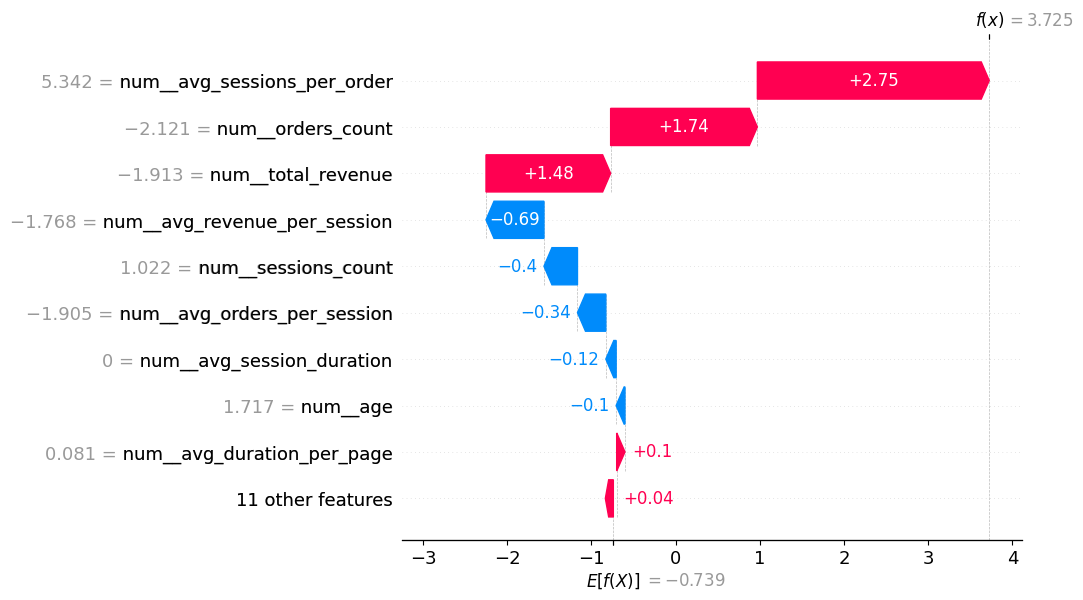

In [65]:
lg_preprocessor = lg_pipeline_full.named_steps['preprocessor']
lg_model = lg_pipeline_full.named_steps['model']
X_test_full_processed = lg_preprocessor.transform(X_test_full)
feature_names = lg_preprocessor.get_feature_names_out()
explainer = shap.LinearExplainer(lg_model, X_test_full_processed)
shap_values = explainer.shap_values(X_test_full_processed)
if isinstance(shap_values, list):
    shap_values_churn = shap_values[1]
else:
    if shap_values.ndim == 3:
        shap_values_churn = shap_values[:, :, 1]
    else:
        shap_values_churn = shap_values

false_negatives = lg_incorrect_predictions_full[lg_incorrect_predictions_full['error_type'] == 'False Negative'].head(3)
false_positives = lg_incorrect_predictions_full[lg_incorrect_predictions_full['error_type'] == 'False Positive'].head(3)

error_cases = pd.concat([false_negatives, false_positives])

positions = X_test_full.index.get_indexer(error_cases.index)

for error_index, position in zip(error_cases.index, positions):
    error_row = error_cases.loc[error_index]

    plot_shap_waterfall_for_errors(
        position=position,
        error_row=error_row,
        shap_values_churn=shap_values_churn,
        explainer=explainer,
        X_processed=X_test_full_processed,
        feature_names=feature_names
    )

# Random Forest Classifier(full)

Actual: 1
Predicted: 0
Churn probability: 0.5
Error type: False Negative


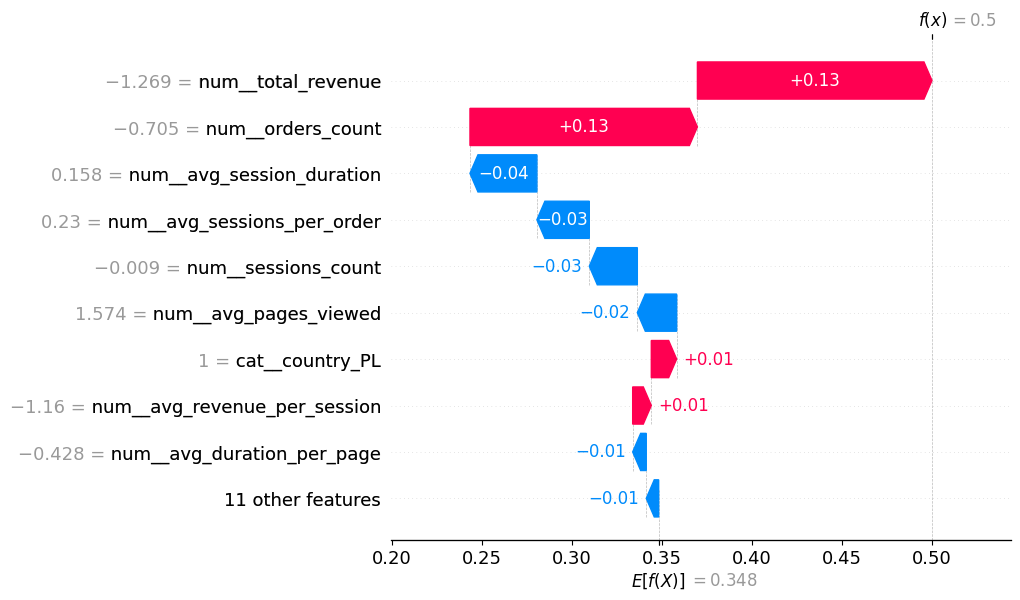

Actual: 1
Predicted: 0
Churn probability: 0.5
Error type: False Negative


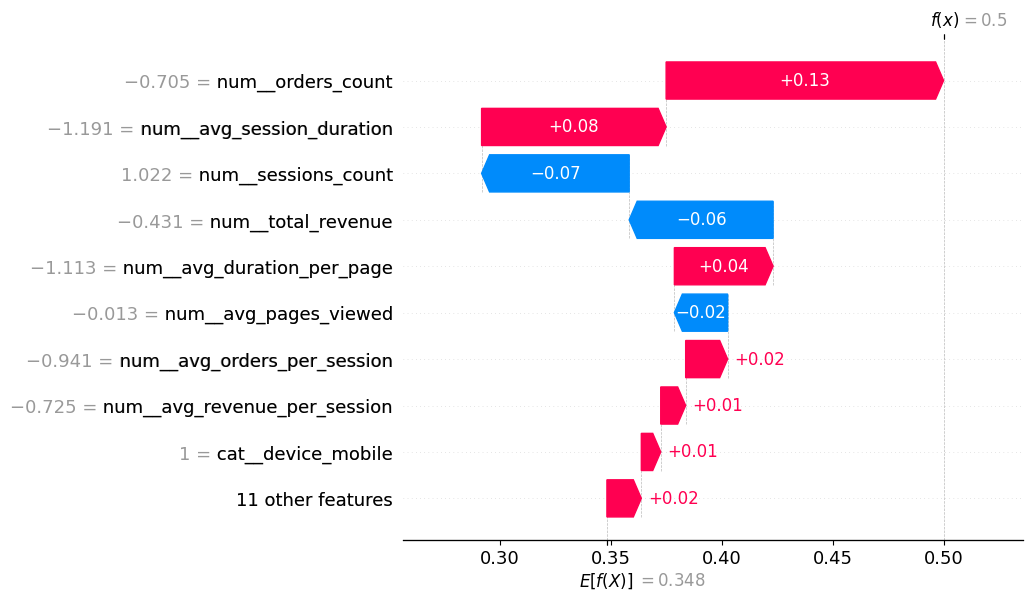

Actual: 1
Predicted: 0
Churn probability: 0.5
Error type: False Negative


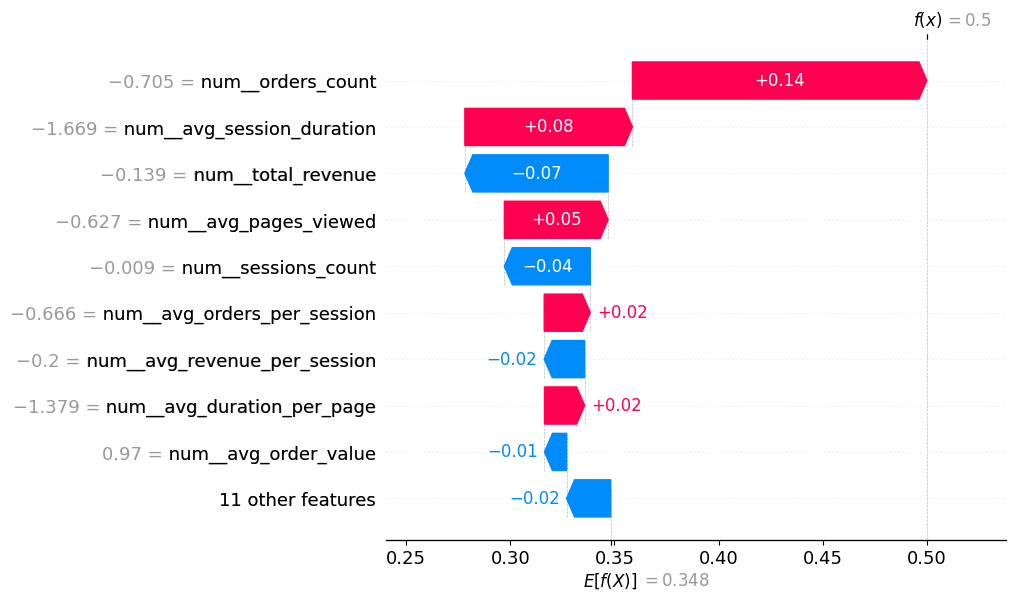

Actual: 0
Predicted: 1
Churn probability: 0.92
Error type: False Positive


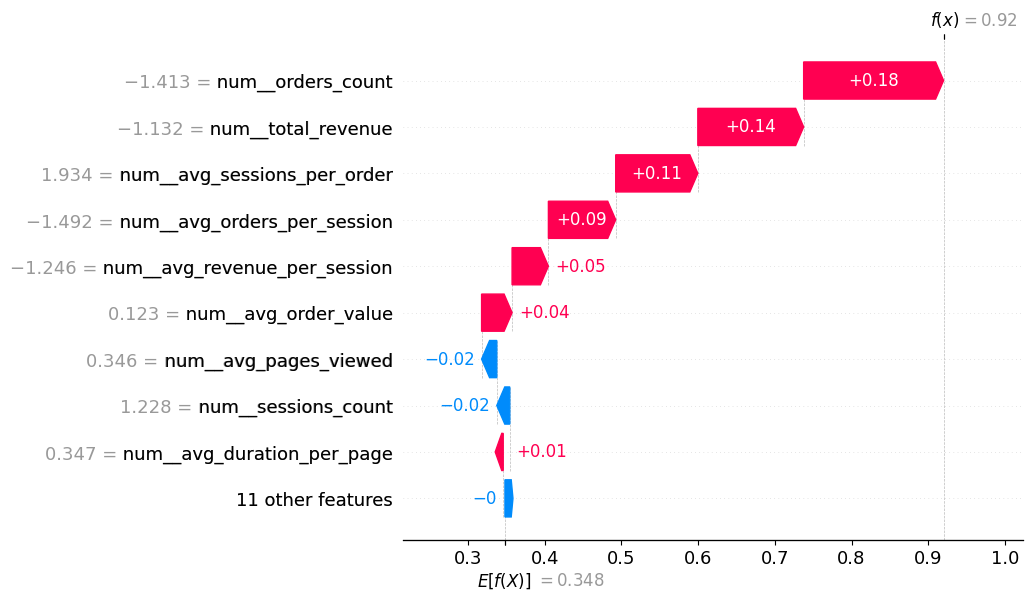

Actual: 0
Predicted: 1
Churn probability: 0.89
Error type: False Positive


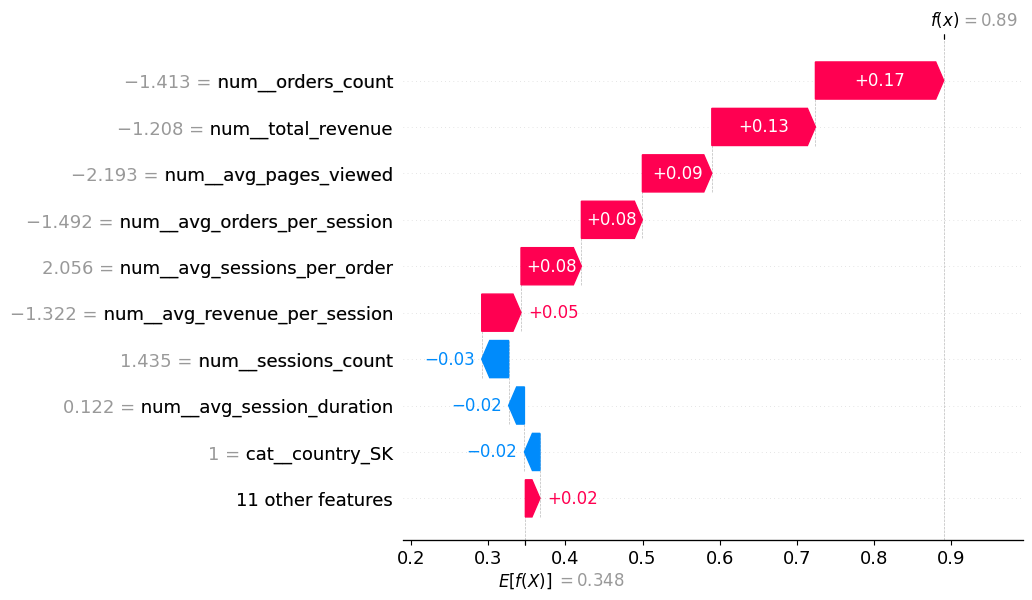

Actual: 0
Predicted: 1
Churn probability: 0.84
Error type: False Positive


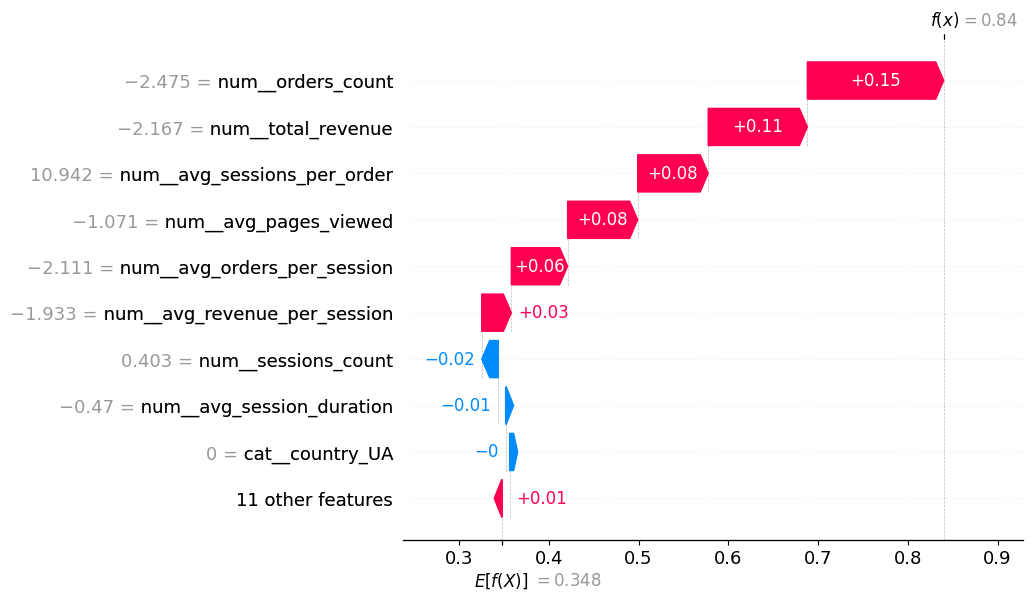

In [66]:
rf_preprocessor = rf_pipeline_full.named_steps['preprocessor']
rf_model = rf_pipeline_full.named_steps['model']
X_test_full_processed = rf_preprocessor.transform(X_test_full)
feature_names = rf_preprocessor.get_feature_names_out()
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_full_processed)
if isinstance(shap_values, list):
    shap_values_churn = shap_values[1]
else:
    if shap_values.ndim == 3:
        shap_values_churn = shap_values[:, :, 1]
    else:
        shap_values_churn = shap_values

false_negatives = rf_incorrect_predictions_full[rf_incorrect_predictions_full['error_type'] == 'False Negative'].head(3)
false_positives = rf_incorrect_predictions_full[rf_incorrect_predictions_full['error_type'] == 'False Positive'].head(3)

error_cases = pd.concat([false_negatives, false_positives])

positions = X_test_full.index.get_indexer(error_cases.index)

for error_index, position in zip(error_cases.index, positions):
    error_row = error_cases.loc[error_index]

    plot_shap_waterfall_for_errors(
        position=position,
        error_row=error_row,
        shap_values_churn=shap_values_churn,
        explainer=explainer,
        X_processed=X_test_full_processed,
        feature_names=feature_names
    )

# Block 10. Advanced Models

# Task 29. XGBoost Baseline

In [67]:
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(random_state= 42, eval_metric="logloss"))
]).fit(X_train, y_train)

# Task 30. XGBoost Evaluation

In [68]:
pred = xgb_pipeline.predict(X_test)
proba = xgb_pipeline.predict_proba(X_test)[:, 1]

xgb_results = pd.DataFrame([
    {
    "Model": "XGBClassifier",
    "Accuracy": accuracy_score(y_test, pred),
    "Precision": precision_score(y_test, pred),
    "Recall": recall_score(y_test, pred),
    "F1": f1_score(y_test, pred),
    "ROC-AUC": roc_auc_score(y_test, proba)
    }
])
xgb_results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,XGBClassifier,0.773,0.693291,0.623563,0.656581,0.849623


# Task 31. XGBoost Tuning

In [69]:
params = {"model__n_estimators": [100, 300, 500],
          "model__max_depth": [3, 5, 7],
          "model__learning_rate": [0.01, 0.05, 0.1],
          "model__subsample": [0.8, 1.0],
          "model__colsample_bytree": [0.8, 1.0]}

grid = GridSearchCV(estimator = xgb_pipeline, param_grid = params, n_jobs = -1, scoring = 'roc_auc', cv = cv, verbose = 2)
grid.fit(X_train, y_train)

print("Best params", grid.best_params_)
print("Best score", grid.best_score_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best params {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__n_estimators': 300, 'model__subsample': 0.8}
Best score 0.863145047981351


# Task 32. Compare the model before and after tuning

In [70]:
tun_xgb_pipeline = grid.best_estimator_
xgb_pipelines = {"XGBClassifier": xgb_pipeline, "Tunning XGBClassifier": tun_xgb_pipeline}
results = []
for name, pipeline in xgb_pipelines.items():
    pred = pipeline.predict(X_test)
    proba = pipeline.predict_proba(X_test)[:, 1]
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, proba)
    })
results = pd.DataFrame(results)
results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,XGBClassifier,0.773,0.693291,0.623563,0.656581,0.849623
1,Tunning XGBClassifier,0.776,0.715278,0.591954,0.647799,0.865802


# Task 33. LightGBM Baseline

In [71]:
lgbm_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LGBMClassifier(random_state=42))
]).fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 1394, number of negative: 2606
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000696 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 953
[LightGBM] [Info] Number of data points in the train set: 4000, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348500 -> initscore=-0.625639
[LightGBM] [Info] Start training from score -0.625639


# Task 34. LightGBM Evaluation

In [72]:
pred = lgbm_pipeline.predict(X_test)
proba = lgbm_pipeline.predict_proba(X_test)[:, 1]

lgbm_results = pd.DataFrame([
    {
    "Model": "LGBMClassifier",
    "Accuracy": accuracy_score(y_test, pred),
    "Precision": precision_score(y_test, pred),
    "Recall": recall_score(y_test, pred),
    "F1": f1_score(y_test, pred),
    "ROC-AUC": roc_auc_score(y_test, proba)
    }
])
lgbm_results

E:\Python\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
E:\Python\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,LGBMClassifier,0.767,0.681388,0.62069,0.649624,0.853492


# Block 11. Final Validation & Model Selection

# Task 35. Final Model Comparison

In [73]:
results = []
final_results = []

pipelines = {"Logistic Regression(Baseline)": lg_pipeline, 
             "Random Forest Classifier(Baseline)": rf_pipeline, 
             "Random Forest Classifier(Tuned)": tun_rf_pipeline,
             "XGBClassifier(Baseline)": xgb_pipeline, 
             "XGBClassifier(Tuned)": tun_xgb_pipeline,
             "LightGBM(Baseline)": lgbm_pipeline}
             

for name, pipeline in pipelines.items():
    pred = pipeline.predict(X_test)
    proba = pipeline.predict_proba(X_test)[:, 1]
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, proba)
    })
final_results = pd.DataFrame(results).sort_values(by= "ROC-AUC", ascending= False)
final_results

E:\Python\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
E:\Python\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
4,XGBClassifier(Tuned),0.776,0.715278,0.591954,0.647799,0.865802
2,Random Forest Classifier(Tuned),0.772,0.700000,0.603448,0.648148,0.859544
5,LightGBM(Baseline),0.767,0.681388,0.620690,0.649624,0.853492
3,XGBClassifier(Baseline),0.773,0.693291,0.623563,0.656581,0.849623
1,Random Forest Classifier(Baseline),0.767,0.691030,0.597701,0.640986,0.847864
0,Logistic Regression(Baseline),0.769,0.709677,0.568966,0.631579,0.815678


# Task 36. Cross-Validation

In [74]:
X_train_final, X_val, y_train_final, y_val = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)

cv_scores = cross_val_score(tun_xgb_pipeline, X_train_final, y_train_final, cv= cv, scoring="roc_auc", n_jobs= -1)

print("CV scores:", cv_scores)
print("Mean ROC-AUC:", cv_scores.mean())
print("Std ROC-AUC:", cv_scores.std())

final_model = tun_xgb_pipeline.fit(X_train_final, y_train_final)

CV scores: [0.84387736 0.85662053 0.85557742 0.88007442 0.8642987 ]
Mean ROC-AUC: 0.8600896860986547
Std ROC-AUC: 0.011935996888754042


# Task 37. ROC Curve / ROC-AUC

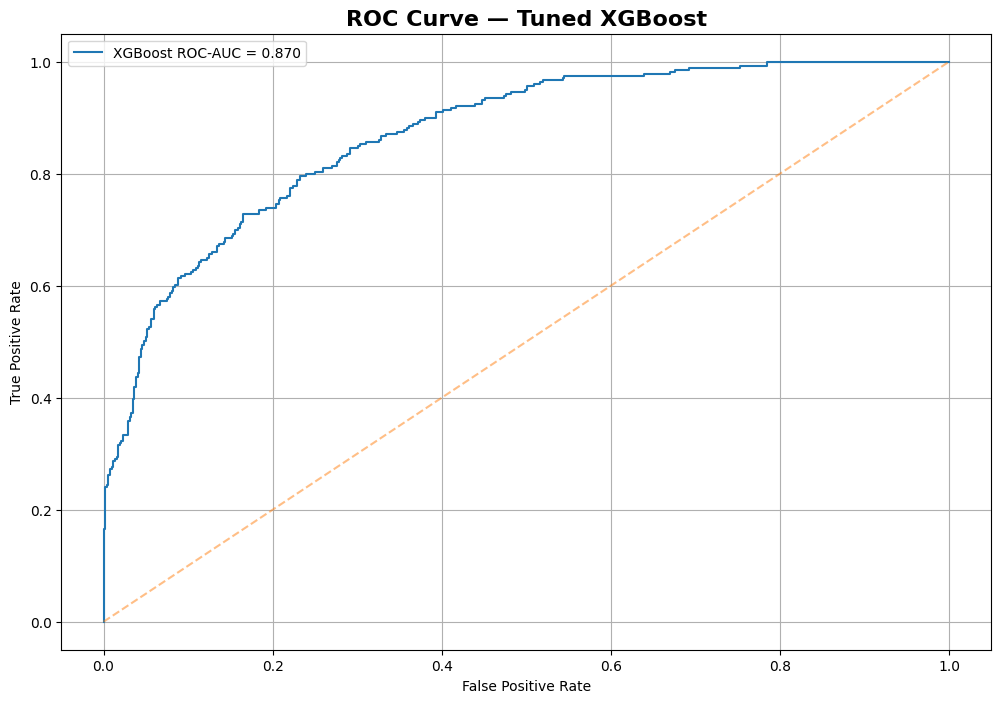

In [75]:
plt.figure(figsize = (12, 8))

val_proba = final_model.predict_proba(X_val)[:, 1]

fpr, tpr, thr = roc_curve(y_val, val_proba)

roc_auc = roc_auc_score(y_val, val_proba)

plt.plot(fpr, tpr, label= f"XGBoost ROC-AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", alpha= 0.5)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Tuned XGBoost", fontsize=16, fontweight="bold")

plt.legend()
plt.grid()
plt.show()

# Task 38. Threshold Tuning

In [76]:
pr, rc, thr = precision_recall_curve(y_val, val_proba)
f1 = 2 * pr * rc / (pr + rc + 1e-20)
idx = f1[:-1].argmax()
best_threshold = thr[idx]

print("Best threshold:", round(best_threshold, 3))
print("Best F1:", round(f1[idx], 3))
print("Precision:", round(pr[idx], 3))
print("Recall:", round(rc[idx], 3))

Best threshold: 0.365
Best F1: 0.715
Precision: 0.702
Recall: 0.728


# Task 39. Final Test Evaluation

In [77]:
test_proba = final_model.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= best_threshold).astype(int)

accuracy = accuracy_score(y_test, test_pred)
precision = precision_score(y_test, test_pred)
recall = recall_score(y_test, test_pred)
f1 = f1_score(y_test, test_pred)
roc_auc = roc_auc_score(y_test, test_proba)

pr, rc, thr = precision_recall_curve(y_test, test_proba)
pr_auc = auc(rc, pr)

print("Threshold:", round(best_threshold, 3))
print("Accuracy:", round(accuracy, 3))
print("Precision:", round(precision, 3))
print("Recall:", round(recall, 3))
print("F1:", round(f1, 3))
print("ROC-AUC:", round(roc_auc, 3))
print("PR-AUC:", round(pr_auc, 3))

Threshold: 0.365
Accuracy: 0.772
Precision: 0.663
Recall: 0.701
F1: 0.682
ROC-AUC: 0.866
PR-AUC: 0.78


# Block 12. Business Results

# Task 40. Churn Probability

In [78]:
X_full = df.drop(columns= ["customer_id", "is_churned"])

churn_probability = final_model.predict_proba(X_full)[:, 1]

df["churn_probability"] = churn_probability

df["predicted_churn"] = (df["churn_probability"] >= best_threshold).astype(int)

# Task 41. High-Risk Customers

In [79]:
df["high_risk"] = (df["churn_probability"] >= 0.7).astype(int)
df[df["high_risk"] == 1].sort_values(by= "churn_probability", ascending= False)

,customer_id,country,age,device,premium_user,orders_count,total_revenue,avg_order_value,sessions_count,avg_session_duration,avg_pages_viewed,is_churned,avg_duration_per_page,avg_sessions_per_order,avg_revenue_per_session,avg_orders_per_session,churn_probability,predicted_churn,high_risk
657,866,UA,68,desktop,0,3,325,108,16,11.00,4.69,1,2.35,5.33,20.31,0.19,0.938047,1,1
218,2731,SK,69,mobile,0,2,212,106,16,11.68,5.19,1,2.25,8.00,13.25,0.12,0.938023,1,1
465,2569,PL,52,mobile,0,3,286,95,20,8.44,5.30,1,1.59,6.67,14.30,0.15,0.937307,1,1
240,3841,UA,21,mobile,1,3,220,73,21,11.41,5.57,1,2.05,7.00,10.48,0.14,0.936983,1,1
187,2886,UA,18,mobile,0,3,200,67,19,10.06,5.42,1,1.86,6.33,10.53,0.16,0.936459,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
862,4116,UA,31,desktop,1,4,362,91,27,10.98,6.30,1,1.74,6.75,13.41,0.15,0.700943,1,1
820,647,HU,46,mobile,0,5,355,71,23,9.36,6.09,1,1.54,4.60,15.43,0.22,0.700880,1,1
312,1279,HU,62,mobile,0,4,245,61,23,15.76,5.74,1,2.75,5.75,10.65,0.17,0.700834,1,1
309,1844,CZ,35,mobile,1,4,245,61,24,8.94,6.13,1,1.46,6.00,10.21,0.17,0.700745,1,1


# Task 42. High-Risk Segment Analysis

# country

In [82]:
customers = pd.DataFrame(df.groupby("country")["customer_id"].count())
high_risk_customers = pd.DataFrame(df.groupby("country")["high_risk"].apply(lambda x: (x == 1).sum()))
result = customers.merge(high_risk_customers, on= "country")
result["high_risk_rate"] = (result["high_risk"] * 100 / result["customer_id"]).round(3)
result = result.rename(columns={"customer_id": "customers",
                                "high_risk": "high_risk_customers"}).sort_values(by= "high_risk_rate", ascending = False)
result

,customers,high_risk_customers,high_risk_rate
country,,,
UA,2069,245,11.841
PL,892,104,11.659
SK,749,79,10.547
CZ,812,81,9.975
HU,478,45,9.414


# Visualize

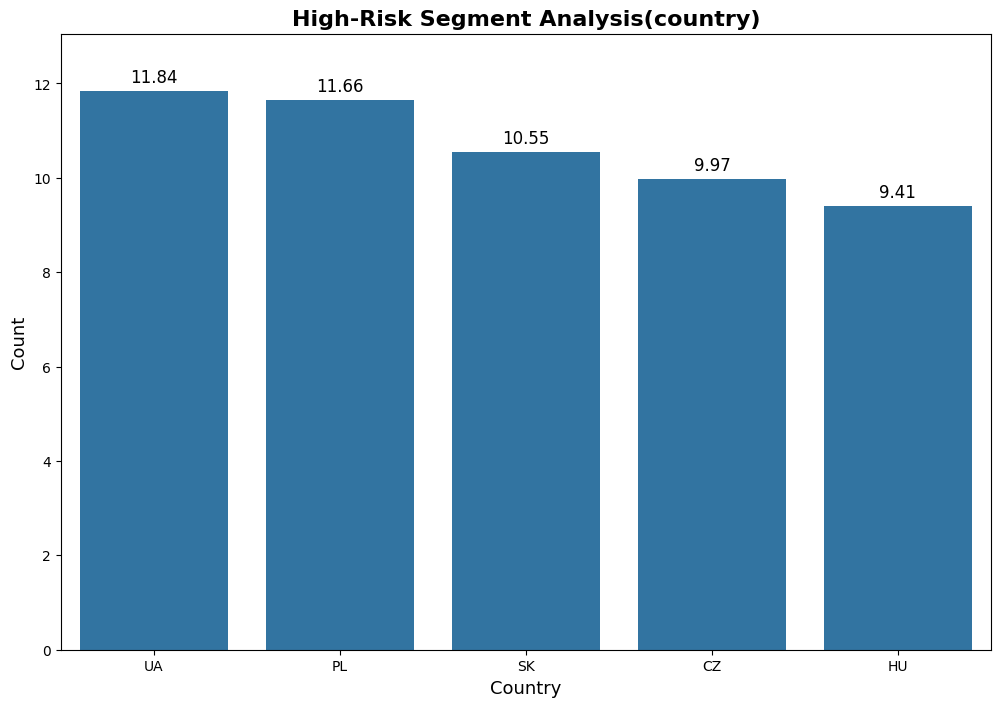

In [83]:
plt.figure(figsize = (12, 8))
ax = sns.barplot(data= result, x= "country", y= "high_risk_rate")
for container in ax.containers:
    ax.bar_label(container, fontsize = 12, fmt= '%.2f', padding = 3)
y_min, y_max = ax.get_ylim()
ax.set_ylim(y_min,  y_max * 1.05)

plt.title("High-Risk Segment Analysis(country)", fontsize=16, fontweight="bold")
plt.xlabel("Country", fontsize = 13)
plt.ylabel("Count", fontsize = 13)

plt.show()

# device

In [84]:
customers = pd.DataFrame(df.groupby("device")["customer_id"].count())
high_risk_customers = pd.DataFrame(df.groupby("device")["high_risk"].apply(lambda x: (x == 1).sum()))
result = customers.merge(high_risk_customers, on= "device")
result["high_risk_rate"] = (result["high_risk"] * 100 / result["customer_id"]).round(3)
result = result.rename(columns={"customer_id": "customers",
                                "high_risk": "high_risk_customers"}).sort_values(by= "high_risk_rate", ascending = False)
result

,customers,high_risk_customers,high_risk_rate
device,,,
desktop,1760,213,12.102
mobile,2743,295,10.755
tablet,497,46,9.256


# Visualize

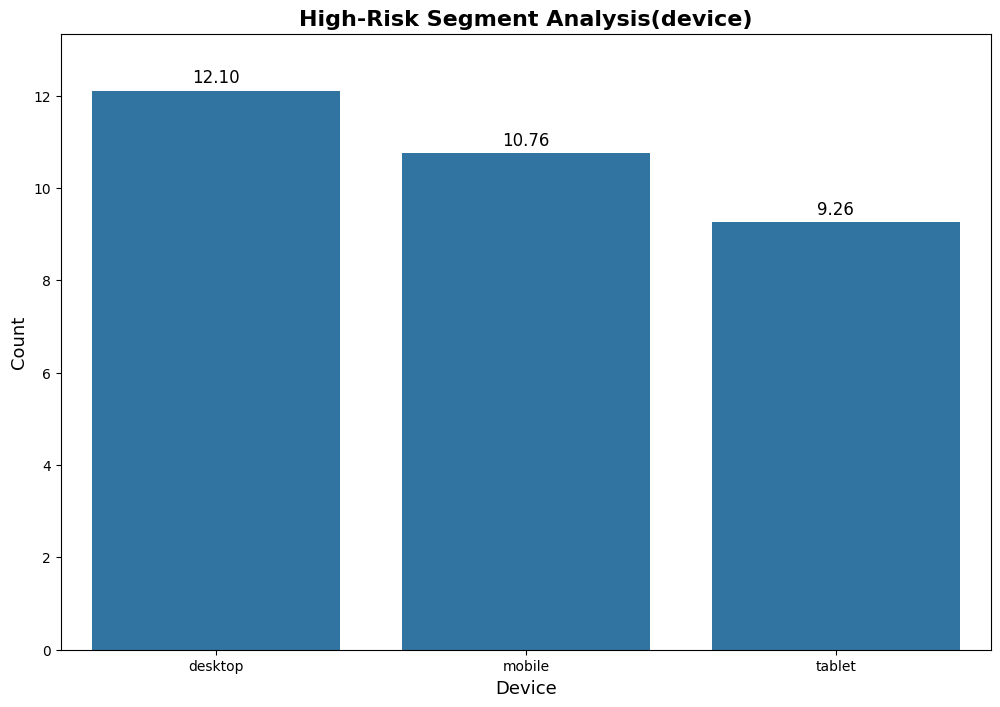

In [85]:
plt.figure(figsize = (12, 8))
ax = sns.barplot(data= result, x= "device", y= "high_risk_rate")
for container in ax.containers:
    ax.bar_label(container, fontsize = 12, fmt= '%.2f', padding = 3)
y_min, y_max = ax.get_ylim()
ax.set_ylim(y_min,  y_max * 1.05)

plt.title("High-Risk Segment Analysis(device)", fontsize=16, fontweight="bold")
plt.xlabel("Device", fontsize = 13)
plt.ylabel("Count", fontsize = 13)

plt.show()

# premium user

In [86]:
customers = pd.DataFrame(df.groupby("premium_user")["customer_id"].count())
high_risk_customers = pd.DataFrame(df.groupby("premium_user")["high_risk"].apply(lambda x: (x == 1).sum()))
result = customers.merge(high_risk_customers, on= "premium_user")
result["high_risk_rate"] = (result["high_risk"] * 100 / result["customer_id"]).round(3)
result = result.rename(columns={"customer_id": "customers",
                                "high_risk": "high_risk_customers"}).sort_values(by= "high_risk_rate", ascending = False)
result

,customers,high_risk_customers,high_risk_rate
premium_user,,,
0,3631,404,11.126
1,1369,150,10.957


# Visualize

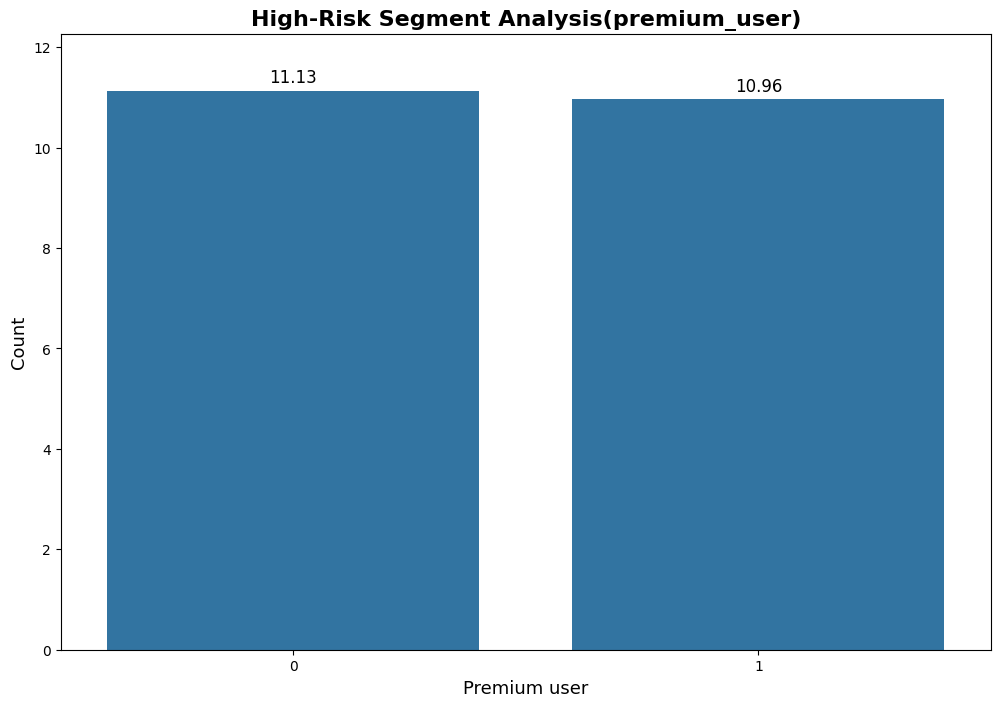

In [87]:
plt.figure(figsize = (12, 8))
ax = sns.barplot(data= result, x= "premium_user", y= "high_risk_rate")
for container in ax.containers:
    ax.bar_label(container, fontsize = 12, fmt= '%.2f', padding = 3)
y_min, y_max = ax.get_ylim()
ax.set_ylim(y_min,  y_max * 1.05)

plt.title("High-Risk Segment Analysis(premium_user)", fontsize=16, fontweight="bold")
plt.xlabel("Premium user", fontsize = 13)
plt.ylabel("Count", fontsize = 13)

plt.show()

# Task 43. Business Recommendations

# 1. Target high-risk country segments

In [ ]:
#Based on country analysis:

#UA — 11.841% high-risk customers — the highest rate.
#PL — 11.659%
#SK — 10.547%
#CZ — 9.975%
#HU — 9.414%

# Recommendation 1 — Targeted Retention Campaign for Ukrainian Customers

# Problem:
# Customers from Ukraine have the highest predicted high-risk level among all analyzed countries.

# Evidence:
# 11.841% of customers from Ukraine are classified as high-risk, compared to 9.414% in Hungary, where this rate is the lowest.

# Recommended Action:
# Launch a targeted retention campaign for high-risk customers from Ukraine. Use personalized offers, email/push notifications, and product recommendations based on their previous activity.

# Business Goal:
# Reduce customer churn in the highest-risk country segment and increase customer retention.

# 2. Target high-risk customers by device

In [ ]:
# Based on device analysis:
    
# Desktops — 12.102%
# Mobile — 10.755%
# Tablets — 9.256%
# Recommendation 2 — Desktop Re-engagement Campaign

# Problem:
# Desktop users have the highest predicted high-risk level among the analyzed device segments.

# Evidence:
# 12.102% of desktop users are classified as high-risk, compared to 9.256% of tablet users.

# Recommended Action:
# Create a targeted re-engagement campaign for high-risk desktop users. Test personalized recommendations, reminders, and special offers.

# Business Goal:
# Increase engagement and reduce predicted churn.

# 3. Target high-risk premium and not premium customers

In [ ]:
# Based on customers analysis:

# Non-Premium — 11.126%
# Premium — 10.957%

# Total difference:

# 0.169 percentage points.

# Recommendation 3 — Maintaining Premium Customer Engagement

# Problem:
# Premium customers have a slightly lower predicted high-risk level, but the difference with non-Premium customers is small.

# Evidence:
# 10.957% of Premium users are considered high-risk compared to 11.126% of non-Premium users.

# Recommended Action:
# Continue to offer loyalty rewards and personalized offers to Premium customers. Monitor churn probability instead of assuming that Premium status alone prevents churn.

# Business Goal:
# Maintain Premium customer retention and identify Premium customers who remain at high risk of churn.

# Task 44. Save Final Model

In [89]:
joblib.dump(final_model, "E:/Python/customer-churn/models/churn_model.pkl")
joblib.dump(best_threshold, "E:/Python/customer-churn/models/сhurn_threshold.pkl")

['E:/Python/customer-churn/models/сhurn_threshold.pkl']

In [120]:
df

,customer_id,country,age,device,premium_user,orders_count,total_revenue,avg_order_value,sessions_count,avg_session_duration,avg_pages_viewed,is_churned,avg_duration_per_page,avg_sessions_per_order,avg_revenue_per_session,avg_orders_per_session,churn_probability,predicted_churn,high_risk
0,4448,UA,33,desktop,0,0,0,0,31,15.65,5.35,0,2.93,0.00,0.00,0.00,0.809697,1,1
1,3426,UA,30,mobile,1,0,0,0,26,16.77,5.96,0,2.81,0.00,0.00,0.00,0.657189,1,0
2,295,HU,44,desktop,0,1,3,3,28,11.93,6.14,1,1.94,28.00,0.11,0.04,0.643885,1,0
3,2997,UA,58,desktop,1,1,11,11,23,14.33,6.17,1,2.32,23.00,0.48,0.04,0.623568,1,0
4,3182,UA,23,tablet,0,1,21,21,22,17.12,5.95,0,2.88,22.00,0.95,0.05,0.614941,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,3753,HU,52,tablet,1,14,1585,113,30,14.20,6.07,0,2.34,2.14,52.83,0.47,0.030128,0,0
4996,304,UA,36,mobile,0,15,1645,110,32,14.23,6.13,0,2.32,2.13,51.41,0.47,0.023943,0,0
4997,3288,CZ,26,desktop,0,16,1647,103,30,18.30,5.93,0,3.09,1.88,54.90,0.53,0.020389,0,0
4998,4840,SK,35,mobile,0,19,1815,96,25,11.66,5.72,0,2.04,1.32,72.60,0.76,0.113269,0,0
